# Continuous time hazards and survival analysis

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
from scipy import special as sp

plt.style.use("bambi.mplstyle")
seed = sum(map(ord, "Survival Continuous Time"))
rng = np.random.default_rng(seed)

## From discrete to continuous time

In this notebook we will explore survival modelling techniques in the continuous time formulation. This modelling strategy is often computationally quite efficient because it allows you to explicitly handle censored data without exploding the dataset size via person-period transformations. The data for some subjects is "censored" if there is no event or state-change recorded for those subjects. If we don't handle this aspect of the sample data correctly we risk skewing our conclusions.

Before we get to the applied sections, we need to establish some theoretical ground. We will:

- Distinguish proportional hazards from accelerated failure time interpretations
- Outline the Weibull as the canonical parametric family for survival modelling
- Describe how parametric models handle censoring

Once this ground is established, we turn to practice. First with a simulation study that recovers known parameters, then with a people analytics example modelling time-to-attrition.

In the companion notebook on [discrete-time survival](survival_discrete_time_notebook.ipynb), we showed how to approach survival analysis by discretizing time into periods and fitting binary regression models with a cloglog link. That approach works well when time is naturally discrete and you want maximum flexibility in the baseline hazard shape, but it requires expanding data to person-period format.

When continuous time is more natural, **parametric continuous-time models** offer a different set of trade-offs:

- **Fewer parameters**: A Weibull model describes the entire baseline hazard with just two numbers (shape and scale)
- **Interpolation and extrapolation**: Smooth hazard functions can predict at any time point, not just observed periods
- **Direct probabilistic interpretation**: The likelihood is defined on the continuous time axis, no discretization needed
- **Efficiency**: No person-period expansion. Each subject contributes one row

The cost is that we must choose a parametric family for the baseline hazard. If we choose poorly, the model is misspecified. This notebook explores these trade-offs. We will step through how to model accumulating risk with various parametric families, culminating in an example of _competing risks_ survival models. 

## Two frameworks for covariate effects

Before fitting any models, we need to understand a conceptual fork in the road. There are two fundamentally different ways to think about how covariates affect survival. In the discrete time formulation we focused on the proportional hazards interpretation, however when shifting to continuous time distributional models the accelerated failure time view becomes available.

::: {.callout-important}
##### Proportional hazards (PH) vs. accelerated failure time (AFT)

**Proportional Hazards (PH)**: Covariates act multiplicatively on the *hazard function*. A treatment that halves the hazard does so at every time point. The hazard function $h(t)$ — the instantaneous rate of event occurrence at time $t$, given survival to $t$ — for subject $i$ is:

$$
h(t \mid \boldsymbol{X}_i) = h_0(t) \cdot \exp(\boldsymbol{X}_i \boldsymbol{\beta})
$$

Coefficients are **log hazard ratios**: $\exp(\beta_j)$ tells you the factor by which the hazard is multiplied for a one-unit increase in $X_j$. This was the interpretation of coefficients we discussed in the discrete time formulations of survival modelling.

**Accelerated Failure Time (AFT)**: Covariates act multiplicatively on the *time scale*. A treatment that doubles survival time "stretches" the time axis by a factor of 2. For the Weibull case, the model is:

$$T_i \sim \text{Weibull}(\alpha, \sigma_i), \qquad \sigma_i = \frac{\mu_i}{\Gamma(1 + 1 / \alpha)}, \qquad \log(\mu_i) = \beta_0 + X_i \gamma$$

where $\alpha$ is the shape parameter (shared across subjects, estimated from data), $\mu_i = E[T_i \mid X_i]$ is the conditional mean, and $\sigma_i$ is the Weibull scale. This is Bambi's parameterization: its log link targets $\mu_i$ and it converts the mean to the scale internally. Coefficients are **log time ratios**: $\exp(\gamma_j)$ tells you the factor by which expected survival time is multiplied for a one-unit increase in $X_j$. Because $\alpha$ is shared, it also multiplies the scale by the same factor.

**The key difference**:

- In PH, a positive coefficient *increases hazard* (bad for survival)
- In AFT, a positive coefficient *increases survival time* (good for survival)
- PH operates on the hazard (vertical axis); AFT operates on time (horizontal axis)
:::

These two frameworks sometimes coincide. For the Weibull distribution, and *only* for the Weibull among standard parametric families, the same model can be written in both PH and AFT form. The exponential is a special case of the Weibull, so it also has this dual representation. For other distributions (log-normal, log-logistic), only the AFT form applies.

Bambi's `family="weibull"` with `link="log"` fits the **AFT parameterization**. We'll see how to convert to PH interpretation later.

## The Weibull distribution: shape and scale

One benefit of parametric approaches to survival modelling is that we can sample and plot the distributional assumptions. Usually with no more than two parameters we can explore a range of time-to-event distributions, and then the questions becomes more applied. Which is the appropriate parametric phrasing of our problem? 

### Why the Weibull?

The Weibull distribution is the workhorse of parametric survival analysis because it is flexible enough to capture three qualitatively different hazard patterns with just two parameters. There are a number of different ways to parameterize the Weibull distribution. The key point is that there is a shape parameter than controls the accumulation of risk.

- **Shape $\alpha < 1$**: Decreasing hazard (early failures, then stabilization. Think of infant mortality or burn-in failures)
- **Shape $\alpha = 1$**: Constant hazard (the exponential distribution is a memoryless process)
- **Shape $\alpha > 1$**: Increasing hazard (wear-out, aging, accumulated damage)

The probability density, survival, and hazard functions used in PyMC and Bambi:

$$
\begin{aligned}
f(t) &= \frac{\alpha}{\sigma}\left(\frac{t}{\sigma}\right)^{\alpha - 1} \exp\left(-\left(\frac{t}{\sigma}\right)^{\alpha}\right) \\
S(t) &= \exp\left(-\left(\frac{t}{\sigma}\right)^{\alpha}\right) \\
h(t) &= \frac{\alpha}{\sigma}\left(\frac{t}{\sigma}\right)^{\alpha - 1}
\end{aligned}
$$

where $\alpha$ is the shape parameter, $\sigma$ is the scale parameter, and $h(t)$ is the hazard function.
The scale sets "how long" things take while the shape determines "how the risk changes over time."

With these properties we plot a range of different types of risk accumulation phenomena.

### We are still modelling risk accumulation

Survival analysis models events as the outcome of an underlying risk accumulation process evolving over time. At each moment, covariates influence the rate at which risk increases, bringing the system closer to a latent transition threshold. Continuous-time models represent the accumulation of risk directly through the hazard and cumulative hazard functions, although these are now derived directly from the PDF and CDF of the parametric distribution.

This is an extra layer of abstraction, and often prevents people from "getting" survival analysis. Not only do you need to understand the idea of latent hazards, but you must work through the seemingly opaque mathematical abstractions of density functions! This is a barrier to understanding, but the core idea is simple: a single parametric distribution gives you the density, survival function, and hazard simultaneously. Choose the distribution, and all three quantities follow.

To gain intuition about these mathematical abstractions it is useful to focus on the histogram of time-to-event distributions. The histogram is a concrete object of study that is naturally translated into an empirical cumulative density function (ECDF). This gives us the proportion of observed events that have occurred by time $t$. This is an approximation of the parametric CDF which (if appropriate to the data) can be translated into the hazard quantities we need for survival modelling. It's a conceptual hook, not an exact identity. The ECDF will be biased unless we are able to handle censoring in the observed data. We'll see how to adjust for this issue below using the properties of the continuous time distribution.

::: {.callout-note collapse="true"}
##### A note on notation

This notebook uses standard survival analysis notation, which differs from Bambi's internal parameterization. The key symbols are:

| Notebook | Meaning | Bambi equivalent |
|----------|---------|------------------|
| $\alpha$ | Weibull shape parameter | `alpha` |
| $\mu_i$ | Conditional Weibull mean, $E[T_i \mid X_i]$ | `mu` (target of the linear predictor) |
| $\sigma$ (or $\sigma_i$) | Weibull scale parameter | `beta` (internal), computed from `mu` and `alpha` |
| $h(t)$ | Hazard function (instantaneous event rate) | — (derived quantity) |
| $\beta_0$ | Intercept of the linear predictor for $\log(\mu)$ | Part of the linear predictor targeting Bambi's `mu` |

The potential point of confusion is the intercept. In the AFT literature, the intercept is commonly denoted $\mu$, often in a linear predictor for $\log(\sigma_i)$. Bambi instead uses `mu` for the **mean of the Weibull distribution**, i.e. $E[T] = \sigma \cdot \Gamma(1 + 1/\alpha)$, and internally converts it to the scale with `beta = mu / gamma(1 + 1/alpha)`. To avoid using $\mu$ for two different quantities, we use $\beta_0$ for the intercept throughout this notebook.

We use $\beta_0$ rather than the more traditional $\mu$ for the intercept to avoid that collision. The simulation below follows Bambi's `mu` parameterization exactly, while $\sigma$, $\alpha$, and $h(t)$ retain their standard Weibull meanings.
:::

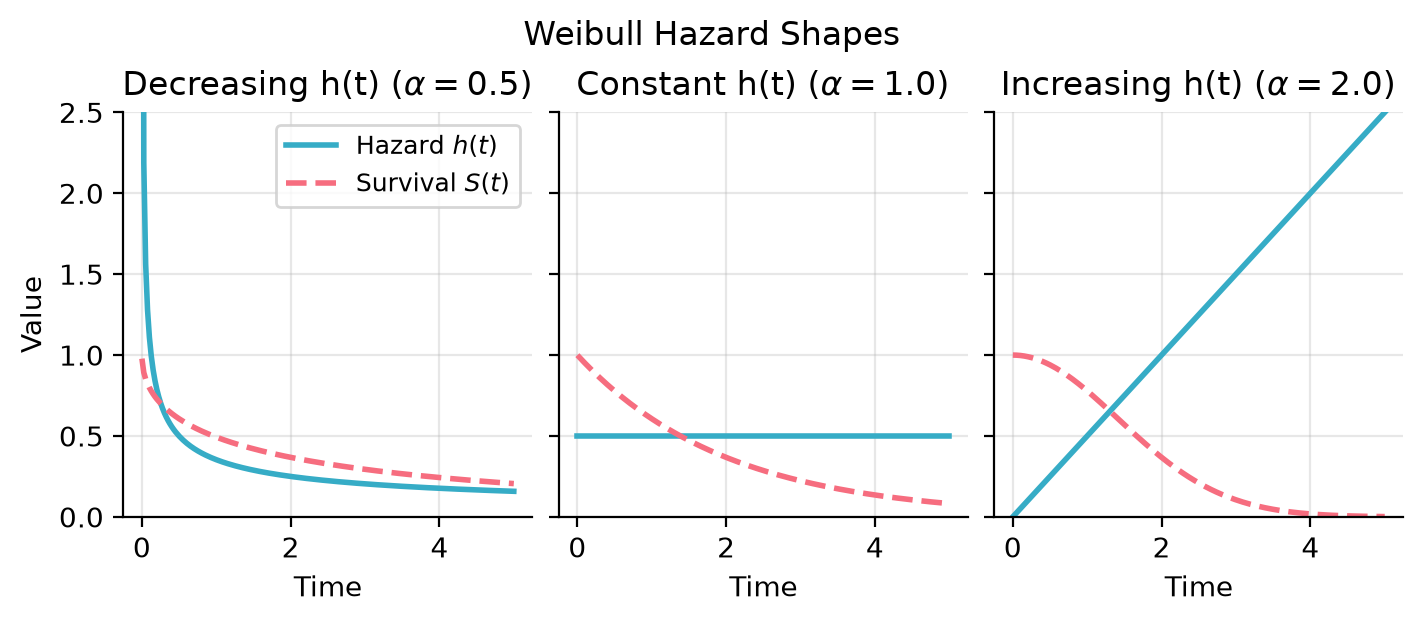

In [2]:
# | code-fold: true
fig, axes = plt.subplots(1, 3, figsize=(7, 3), sharey=True)
t = np.linspace(0.001, 5, 200)
scale = 2.0

for alpha, ax, title in zip(
    [0.5, 1.0, 2.0],
    axes,
    [
        r"Decreasing h(t) ($\alpha=0.5$)",
        r"Constant h(t) ($\alpha=1.0$)",
        r"Increasing h(t) ($\alpha=2.0$)",
    ],
):
    distribution = pz.Weibull(alpha=alpha, beta=scale)
    survival = distribution.sf(t)
    hazard = distribution.pdf(t) / survival
    ax.plot(t, hazard, color="C0", linewidth=2, label="Hazard $h(t)$")
    ax.plot(t, survival, color="C1", ls="--", linewidth=2, label="Survival $S(t)$")
    ax.set(xlabel="Time", title=title, ylim=(0, 2.5))
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=9)
axes[0].set(ylabel="Value")
fig.suptitle("Weibull Hazard Shapes");

The shape parameter is what makes the Weibull so useful: it lets the data tell us whether risk is increasing, decreasing, or constant over time. The exponential model forces $\alpha = 1$ — a strong and often unrealistic assumption. So we can move between different views of accumulating risk with these parametric families, but how do we handle censored data?

### How parametric models handle censoring

One major advantage of continuous-time parametric models is that censoring is handled *directly in the likelihood*, without expanding the dataset or imputing missing event times.

Suppose for each individual we observe:

- $t_i$ = observed time  
- $\delta_i$ = event indicator  
  - $\delta_i = 1$ if the event occurred  
  - $\delta_i = 0$ if the observation is right-censored  

In a parametric survival model, we specify a probability density function $f(t \mid \theta)$ and corresponding survival function $S(t \mid \theta)$.

#### Likelihood contribution

Each individual contributes:

- If the event is observed ($\delta_i = 1$):  
  $$
  f(t_i \mid \theta)
  $$

- If the observation is right-censored ($\delta_i = 0$):  
  $$
  S(t_i \mid \theta)
  $$

Why? Because censoring means:

> The event time exceeds $t_i$.

And by definition:

$$
P(T > t_i) = S(t_i)
$$

So the full likelihood is:

$$
L(\theta)
=
\prod_{i=1}^n
\left[
f(t_i \mid \theta)
\right]^{\delta_i}
\left[
S(t_i \mid \theta)
\right]^{1 - \delta_i}
$$

This is sometimes called the *censored likelihood* or *partial observation likelihood*.

### Intuition

- Events contribute density mass at the observed time.
- Censored observations contribute probability mass to the right of the observed time.
- No data expansion is required.
- No bias is introduced, provided the censoring is non-informative.

This is fundamentally different from the naive ECDF, which treats censored observations as if the event never occurred and therefore produces inconsistent estimates of the true distribution.

## Simulation: understanding the AFT parameterization

We're now equipped with all the pieces to understand survival modelling in continuous time settings. Let's make it more concrete by simulating data from an AFT process. 

### Generating data from a known AFT model

To build intuition, we first simulate data from a Weibull AFT model with known parameters, then check that we can recover them. This validation step is essential before trusting any model on real data.

The AFT model fitted below by Bambi gives each subject a Weibull distribution whose *mean* depends on their covariates, while the *shape* is shared across all subjects:

$$T_i \sim \text{Weibull}(\alpha, \sigma_i), \qquad \sigma_i = \frac{\mu_i}{\Gamma(1 + 1 / \alpha)}, \qquad \log(\mu_i) = \beta_0 + X_i\beta$$

The model estimates two things: the shape $\alpha$ (which controls how hazard evolves over time i.e. increasing, constant, or decreasing) and the covariate coefficients $\beta$ (which shift each subject's conditional mean survival time). Positive $\beta$ values *increase* the mean, which *stretches* survival times implying the subject lives longer.

::: {.callout-tip collapse="true"}
##### The AFT error-term notation

The AFT literature often writes the same model as $\log(T_i) = \beta_0 + X_i\beta + \sigma \epsilon_i$, where $\epsilon_i$ follows a standard extreme value distribution and $\sigma = 1/\alpha$. This is mathematically equivalent. Taking the log of a Weibull random variable produces an extreme value variate, and the Weibull shape $\alpha$ determines how dispersed these log-times are. We prefer the distributional form above because it maps directly to the code and avoids the potentially confusing $\sigma \epsilon_i$ product notation.
:::

In the simulation code below, this mapping is concrete:

- `log_mu = intercept_true + beta_treatment * treatment + beta_age * age` computes $\log(\mu_i) = \beta_0 + X_i\beta$ for every subject
- `mu = np.exp(log_mu)` exponentiates to get the conditional Weibull means $\mu_i$
- `scale = mu / sp.gamma(1 + 1 / shape_true)` converts each mean to the Weibull scale $\sigma_i$
- `pz.Weibull(alpha=shape_true, beta=scale).rvs(n, random_state=rng)` draws $n$ independent $T_i \sim \text{Weibull}(\alpha, \sigma_i)$ values at once

The shape `shape_true` ($\alpha = 2$) is the same for every subject. It's a global parameter, while the mean—and therefore the scale—varies with covariates.

::: {.callout-note collapse="true"}
##### Can $\alpha$ depend on covariates too?

In principle, yes! You could let the shape vary across subjects, so that different groups have qualitatively different hazard trajectories (e.g., increasing hazard for one group, decreasing for another). This falls under the umbrella of **distributional regression** (sometimes called GAMLSS), where every parameter of the response distribution can have its own linear predictor.

In practice, the standard AFT and PH models keep $\alpha$ shared. This is partly convention, partly pragmatism: estimating covariate effects on the shape requires considerably more data, and interpretation becomes harder. You're then no longer just shifting survival times, but changing the *character* of the hazard over time. For this notebook we stick with the standard shared-$\alpha$ formulation, but it's worth knowing the extension exists when you have strong reason to believe hazard shapes differ across groups.
:::

In [3]:
# Sample size and covariates
n = 1000
treatment = rng.binomial(1, 0.5, n)
age = rng.normal(0, 1, n)

# True AFT parameters
shape_true = 2.0  # Weibull shape (hazard increases over time)
beta_treatment = 0.6  # Positive = LONGER survival in AFT
beta_age = -0.5  # Negative = SHORTER survival
intercept_true = 3.0  # Log-mean intercept (Bambi's mu parameter)

# Generate survival times from Weibull AFT
max_followup = 65

# Bambi's log link targets the conditional Weibull mean
log_mu = intercept_true + beta_treatment * treatment + beta_age * age
mu = np.exp(log_mu)
scale = mu / sp.gamma(1 + 1 / shape_true)

# Independent draws from Weibull(shape, scale)
uncensored_times = pz.Weibull(alpha=shape_true, beta=scale).rvs(n, random_state=rng)

# Administrative censoring at max_followup
events = (uncensored_times <= max_followup).astype(int)
times = np.minimum(uncensored_times, max_followup)

df = pd.DataFrame(
    {
        "time": times,
        "event": np.asarray(events),
        "treatment": np.asarray(treatment),
        "age": np.asarray(age),
    }
)

print("SIMULATION PARAMETERS")
print("---------------------")
print("True AFT coefficients:")
print(f"  Intercept (log-mean) = {intercept_true}")
print(f"  beta_treatment = {beta_treatment} (positive = longer survival)")
print(f"  beta_age = {beta_age} (negative = shorter survival)")
print(f"  shape (alpha) = {shape_true}")
print(f"\nEvents: {df['event'].sum()} ({100*df['event'].mean():.1f}%)")
print(f"Censored: {(1 - df['event']).sum():.0f} ({100*(1-df['event'].mean()):.1f}%)")

SIMULATION PARAMETERS
---------------------
True AFT coefficients:
  Intercept (log-mean) = 3.0
  beta_treatment = 0.6 (positive = longer survival)
  beta_age = -0.5 (negative = shorter survival)
  shape (alpha) = 2.0

Events: 897 (89.7%)
Censored: 103 (10.3%)


### Visualizing the AFT effect

The hallmark of an AFT model is that covariates shift survival times *horizontally* — they stretch or compress the time axis. Compare this to a proportional hazards model, where covariates shift the survival curve *vertically* (by scaling the hazard).

The treated group's distribution is shifted RIGHT along the time axis.
The AFT acceleration factor is exp(0.6) = 1.82x.
This means treatment multiplies expected survival time by ~1.82.


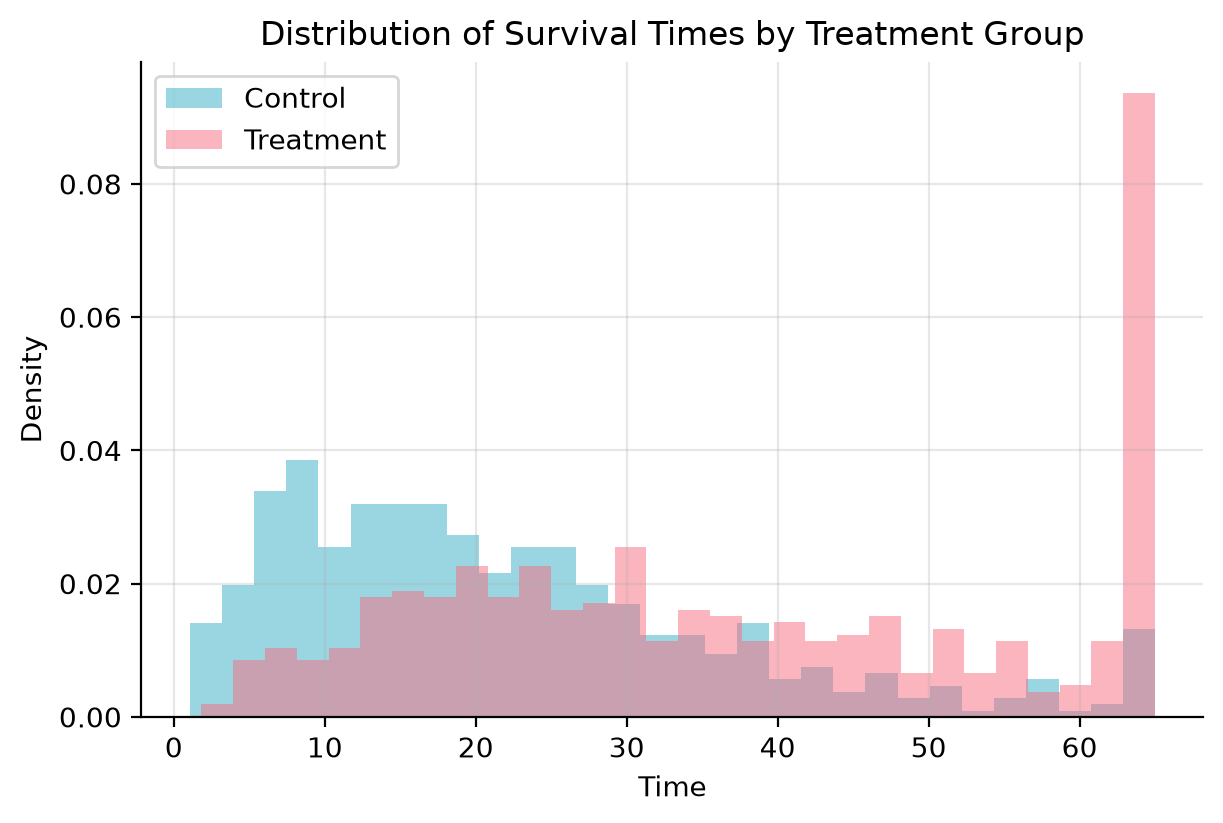

In [4]:
# | code-fold: true
# | fig-cap: Treatment shifts the survival time distribution to the right — the AFT effect 'stretches' the time axis.

fig, ax = plt.subplots()

ax.hist(
    df.loc[df["treatment"] == 0, "time"],
    bins=30,
    alpha=0.5,
    density=True,
    label="Control",
)
ax.hist(
    df.loc[df["treatment"] == 1, "time"],
    bins=30,
    alpha=0.5,
    density=True,
    label="Treatment",
)
ax.set_xlabel("Time")
ax.set_ylabel("Density")
ax.set_title("Distribution of Survival Times by Treatment Group")
ax.legend()
ax.grid(True, alpha=0.3)

print("The treated group's distribution is shifted RIGHT along the time axis.")
print(
    f"The AFT acceleration factor is exp({beta_treatment}) = {np.exp(beta_treatment):.2f}x."
)
print("This means treatment multiplies expected survival time by ~1.82.")

Notice how the treatment group's distribution is shifted *rightward* (longer times), not just compressed downward. This horizontal shift is the signature of an AFT effect. In a PH model, the curves would have the same shape, but one would be uniformly "pulled down" toward zero.

## Fitting parametric models with Bambi

### Handling censoring in Bambi

Right-censoring occurs when we observe a subject for some period, but the event hasn't happened by the end of observation. The subject contributes partial information: we know they survived *at least* until the censoring time, but not how much longer they would have survived.

In Bambi, we handle this with the `censored()` function in the formula. We create a column indicating the censoring status:

- `'none'`: the event was observed (uncensored)
- `'right'`: the subject was right-censored (still alive at last observation)

The censored likelihood correctly accounts for this: uncensored observations contribute the density $f(t)$ to the likelihood, while right-censored observations contribute $S(t)$ — the probability of surviving past the observed time.

In [5]:
# Create censoring indicator for Bambi
df["censoring"] = np.where(df["event"] == 1, "none", "right")

print("Censoring distribution:")
print(df["censoring"].value_counts())

Censoring distribution:
censoring
none     897
right    103
Name: count, dtype: int64


### Weibull AFT model

We now can specify the Weibull AFT model using a convenient formula syntax and the appropriate link function. 

In [6]:
# Fit Weibull AFT model
model_aft = bmb.Model(
    "censored(time, censoring) ~ treatment + age", data=df, family="weibull", link="log"
)
model_aft

       Formula: censored(time, censoring) ~ treatment + age
        Family: weibull
          Link: mu = log
  Observations: 1000
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 3.5446)
            treatment ~ Normal(mu: 0.0, sigma: 5.0)
            age ~ Normal(mu: 0.0, sigma: 2.5191)
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)

Estimating the model with the standard fit call. 

In [7]:
idata_aft = model_aft.fit(random_seed=seed, target_accept=0.99)
model_aft.compute_log_likelihood(idata_aft)

NUTS[nutpie]: [alpha, treatment, age, Intercept_centered]


Output()

In [8]:
summary_aft = az.summary(
    idata_aft, var_names=["Intercept", "treatment", "age", "alpha"]
)
summary_aft

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.9983,0.0233,3,3,3601,2857,1.00,0.00039,0.00038
treatment,0.618,0.033,0.57,0.67,3300,2692,1.00,0.00058,0.00057
age,-0.4633,0.0184,-0.49,-0.43,3051,2502,1.00,0.00033,0.00032
alpha,2.048,0.055,2,2.1,3226,2504,1.00,0.00097,0.00086


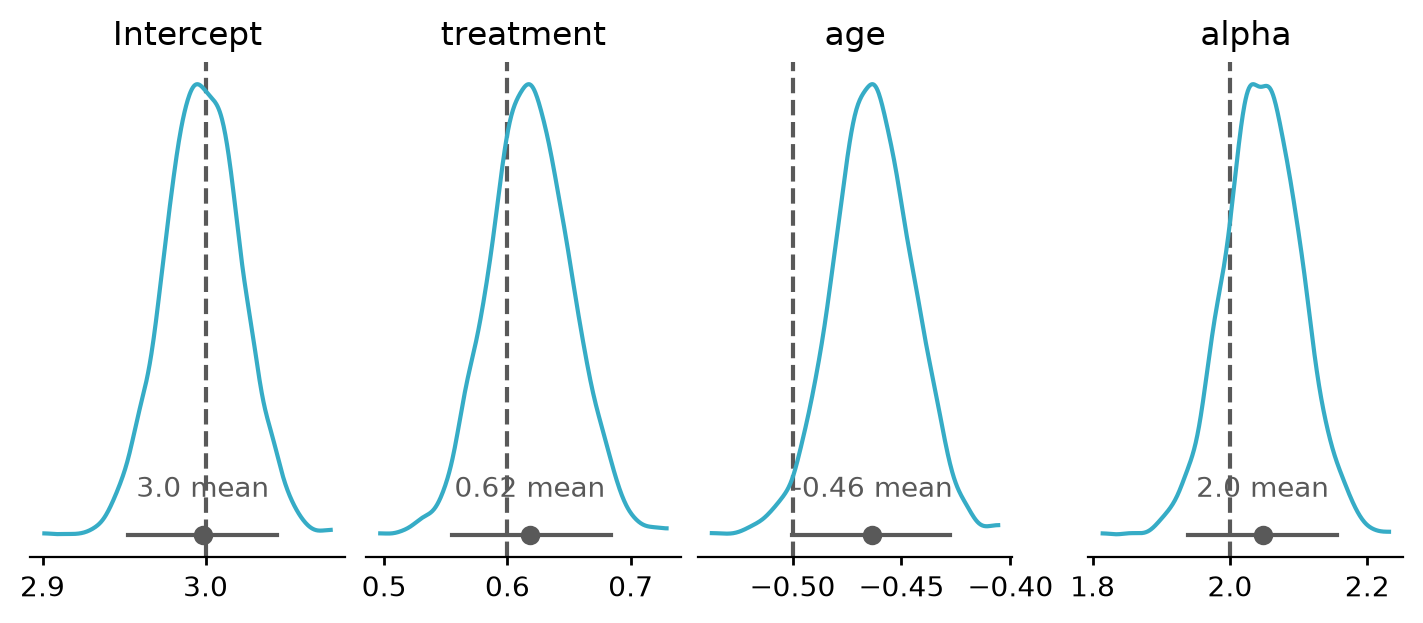

In [9]:
pc = az.plot_dist(
    idata_aft,
    var_names=["Intercept", "treatment", "age", "alpha"],
    ci_prob=0.95,
    figure_kwargs={"figsize": (7, 3)},
)
az.add_lines(
    pc,
    {
        "Intercept": intercept_true,
        "treatment": beta_treatment,
        "age": beta_age,
        "alpha": shape_true,
    },
);

Which nicely recovers the true data generating parameters.

::: {.callout-note}
## Interpreting AFT coefficients

The coefficients from a Weibull AFT model with `link="log"` are **log time-acceleration factors**:

- `treatment = 0.6` means treatment multiplies survival time by $\exp(0.6) \approx 1.82$. Treated subjects live about 82% longer in expectation.
- `age = -0.4` means a one-SD increase in age multiplies survival time by $\exp(-0.4) \approx 0.67$. This is a truncation effect. Older subjects have about 33% shorter survival times.

The sign convention is the *opposite* of proportional hazards: positive AFT coefficients are *protective* (longer survival), while positive PH coefficients are *harmful* (higher hazard).
:::

### Diagnostics

Before interpreting results, we should check that the sampler converged and mixed well.

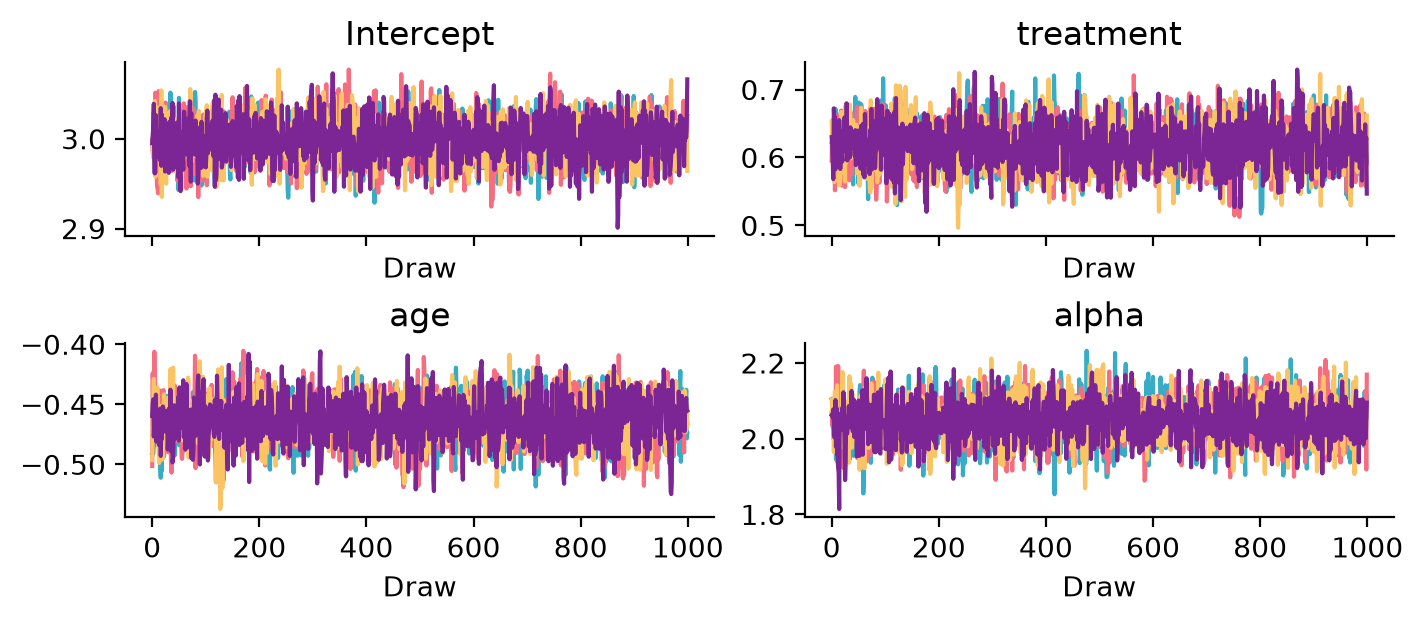

In [10]:
# | fig-cap: Trace plots for the Weibull AFT model. Look for 'fuzzy caterpillars' in the trace (right) and overlapping densities across chains (left).
az.plot_trace(
    idata_aft,
    var_names=["Intercept", "treatment", "age", "alpha"],
    figure_kwargs={"figsize": (7, 3)},
    col_wrap=2,
);

Check for divergences and R-hat values:

In [11]:
divergences = idata_aft.sample_stats["diverging"].sum().values
print(f"Number of divergent transitions: {divergences}")
print(f"All R-hat values < 1.01: {(summary_aft['r_hat'] < 1.01).all()}")

Number of divergent transitions: 0
All R-hat values < 1.01: True


### Exponential model (nested comparison)

The exponential distribution is a Weibull with shape $\alpha = 1$, meaning the hazard is constant over time. Fitting an exponential model lets us test whether the data supports time-varying hazard.

In [12]:
model_exp = bmb.Model(
    "censored(time, censoring) ~ treatment + age",
    data=df,
    family="exponential",
    link="log",
)

idata_exp = model_exp.fit(random_seed=seed)
model_exp.compute_log_likelihood(idata_exp)

NUTS[nutpie]: [treatment, age, Intercept_centered]


Output()

In [13]:
az.summary(idata_exp, var_names=["Intercept", "treatment", "age"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,3.012,0.046,2.9,3.1,6105,3104,1.00,0.00059,0.00073
treatment,0.731,0.067,0.62,0.84,5740,3285,1.00,0.00089,0.0011
age,-0.5356,0.035,-0.59,-0.48,5975,3299,1.00,0.00045,0.00055


### Model comparison

We compare models using Leave-One-Out cross-validation (LOO-CV), which estimates the out-of-sample predictive accuracy of each model. Lower ELPD (expected log pointwise predictive density) differences indicate worse fit; the best model is ranked first.

In [14]:
compare_df = az.compare({"Weibull": idata_aft, "Exponential": idata_exp})
compare_df

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Weibull,0,0.0,0.0,NaN,,,4.2,-3600.0,33.0,1.0
Exponential,1,-260.0,17.0,1.0,,,1.2,-3870.0,36.0,0.0


The Weibull model fits substantially better because the true data-generating process has shape $\alpha = 2$ (increasing hazard). The exponential model, forced to assume constant hazard ($\alpha = 1$), cannot capture this pattern. This is a useful diagnostic: if the exponential fits just as well as the Weibull, it suggests the hazard may indeed be roughly constant.

## Converting between AFT and PH interpretations

### The Weibull duality

The Weibull is unique among parametric survival distributions: the same model can be written in both AFT and PH form. This duality is extremely useful — it means we can fit the model in whichever parameterization is convenient and convert to the other for interpretation.

The relationship between AFT coefficients ($\beta_{\text{AFT}}$) and PH coefficients ($\beta_{\text{PH}}$) for a Weibull with shape parameter $\alpha$ is:

$$\beta_{\text{PH}} = -\alpha \cdot \beta_{\text{AFT}}$$

and the corresponding hazard ratio is:

$$\text{HR} = \exp(\beta_{\text{PH}}) = \exp(-\alpha \cdot \beta_{\text{AFT}})$$

This works because the Weibull hazard is $\lambda(t) = (\alpha / \sigma)(t/\sigma)^{\alpha-1}$, so changing the scale $\sigma$ by a factor $\exp(\beta_{\text{AFT}})$ changes the hazard by a factor $\exp(-\alpha \cdot \beta_{\text{AFT}})$.

::: {.callout-warning}
##### This conversion is Weibull-specific

The AFT-to-PH conversion $\beta_{\text{PH}} = -\alpha \cdot \beta_{\text{AFT}}$ holds **only for the Weibull** (including the exponential as a special case with $\alpha = 1$). For other distributions like the log-normal or log-logistic, only the AFT interpretation is valid. There is no equivalent PH representation because those distributions do not entail proportional hazards.
:::

In [15]:
# Extract posterior samples
beta_aft_treatment = idata_aft.posterior["treatment"]
alpha = idata_aft.posterior["alpha"]

# Convert AFT to PH scale
beta_ph_treatment = -alpha * beta_aft_treatment
hazard_ratio = np.exp(beta_ph_treatment)

print("CONVERTING AFT TO HAZARD RATIOS")
print("===============================")
print(f"AFT coefficient (posterior mean):  {float(beta_aft_treatment.mean()):.3f}")
print(
    f"Time acceleration factor:          {float(np.exp(beta_aft_treatment.mean())):.3f}"
)
print(f"PH coefficient (posterior mean):   {float(beta_ph_treatment.mean()):.3f}")
print(f"Hazard ratio (posterior mean):     {float(hazard_ratio.mean()):.3f}")
print()
print("Interpretation (two equivalent views):")
print(
    f"  AFT: Treatment multiplies survival time by ~{float(np.exp(beta_aft_treatment.mean())):.2f}x"
)
print(f"  PH:  Treatment multiplies hazard by ~{float(hazard_ratio.mean()):.2f}x")
print()
print("Both are consistent: longer survival <=> lower hazard.")

CONVERTING AFT TO HAZARD RATIOS
AFT coefficient (posterior mean):  0.618
Time acceleration factor:          1.856
PH coefficient (posterior mean):   -1.266
Hazard ratio (posterior mean):     0.283

Interpretation (two equivalent views):
  AFT: Treatment multiplies survival time by ~1.86x
  PH:  Treatment multiplies hazard by ~0.28x

Both are consistent: longer survival <=> lower hazard.


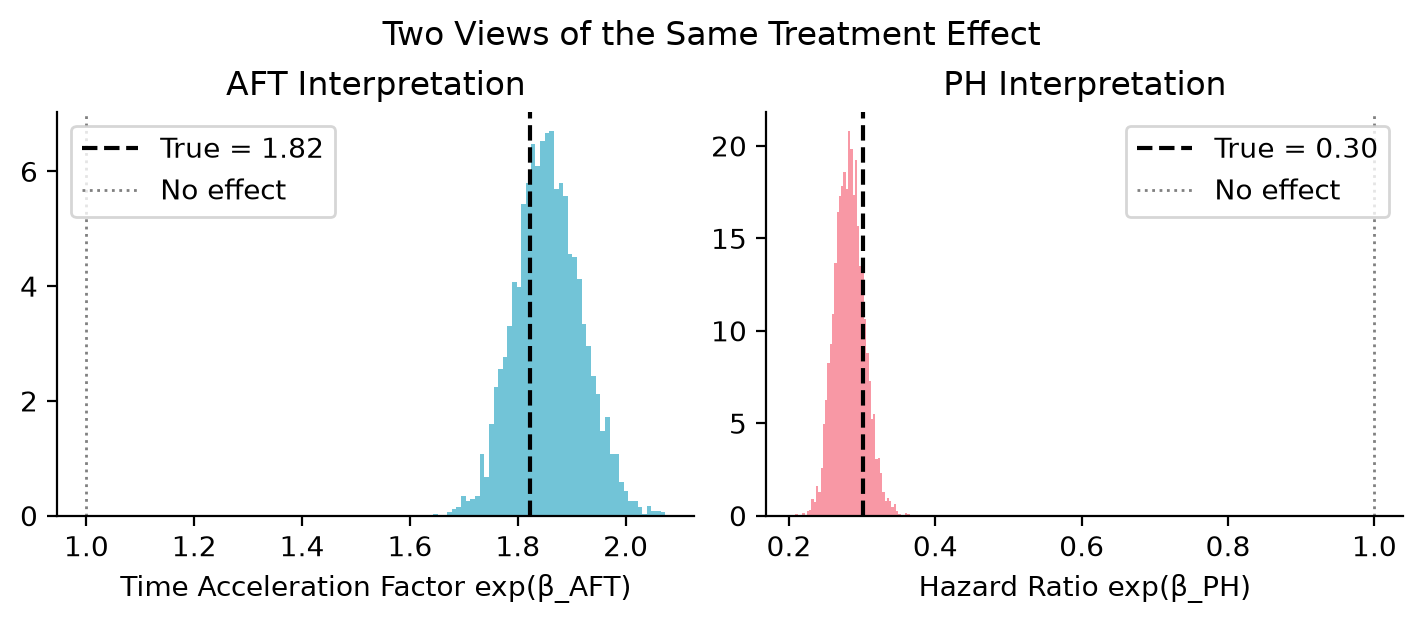

In [16]:
# | fig-cap: The same treatment effect expressed in AFT (time ratio) and PH (hazard ratio) scales. These are two lenses on the same underlying quantity.
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# AFT scale: time acceleration factor
time_ratio = np.exp(beta_aft_treatment).values.flatten()
axes[0].hist(time_ratio, bins=50, density=True, alpha=0.7, color="C0")
axes[0].axvline(
    np.exp(beta_treatment),
    color="black",
    linestyle="--",
    label=f"True = {np.exp(beta_treatment):.2f}",
)
axes[0].axvline(1.0, color="gray", linestyle=":", linewidth=1, label="No effect")
axes[0].set(xlabel="Time Acceleration Factor exp(β_AFT)", title="AFT Interpretation")
axes[0].legend(loc="upper left")

# PH scale: hazard ratio
hr = hazard_ratio.values.flatten()
axes[1].hist(hr, bins=50, density=True, alpha=0.7, color="C1")
axes[1].axvline(
    np.exp(-shape_true * beta_treatment),
    color="black",
    linestyle="--",
    label=f"True = {np.exp(-shape_true * beta_treatment):.2f}",
)
axes[1].axvline(1.0, color="gray", linestyle=":", linewidth=1, label="No effect")
axes[1].set(xlabel="Hazard Ratio exp(β_PH)", title="PH Interpretation")
axes[1].legend(loc="upper right")

fig.suptitle("Two Views of the Same Treatment Effect");

## Deriving survival and hazard curves

A fitted parametric model is only useful if we can translate its coefficients back into the quantities that matter: *how does the probability of surviving change over time, and how does the instantaneous risk evolve?* In this section we derive full survival and hazard curves from the fitted Weibull AFT model using two complementary approaches.

### Approach 1: parametric closed-form curves

The great advantage of a parametric model is that the survival and hazard functions have closed-form expressions. For a Weibull AFT model with shape $\alpha$ and subject-specific scale $\sigma_i = \exp(\beta_0 + X_i \beta)$, we have:

$$\lambda(t \mid X_i) = \frac{\alpha}{\sigma_i}\left(\frac{t}{\sigma_i}\right)^{\alpha - 1}, \qquad S(t \mid X_i) = \exp\left(-\left(\frac{t}{\sigma_i}\right)^{\alpha}\right)$$

Since we have full posterior samples for $\alpha$, $\beta_0$ (intercept), and $\beta$, we can compute these curves for *every posterior draw* and then summarize with pointwise means and credible intervals. This propagates all parameter uncertainty into the curve estimates as desired. 

In [17]:
def get_estimated_curves_weibull(model, idata, t_grid, data):
    predictions = model.predict(idata, kind="response_params", inplace=False, data=data)
    mu = az.extract(predictions, group="predictions", var_names=["mu"]).to_numpy().T
    alpha = az.extract(predictions, group="posterior", var_names=["alpha"]).to_numpy()

    # Broadcast
    mu = mu[:, np.newaxis]
    alpha = alpha[:, np.newaxis, np.newaxis]
    t_grid = t_grid[np.newaxis, :, np.newaxis]

    beta = mu / sp.gamma(1 + 1 / alpha)
    weibull = pz.Weibull(alpha=alpha, beta=beta)

    survival = weibull.sf(t_grid)
    hazard = weibull.pdf(t_grid) / survival
    cum_hazard = -np.log(survival)

    return {"survival": survival, "hazard": hazard, "cum_hazard": cum_hazard}


def get_true_curves_weibull(
    intercept_true, beta_treatment, beta_age, shape_true, t_grid, data
):
    mu = np.exp(
        intercept_true
        + beta_treatment * data["treatment"].to_numpy()
        + beta_age * data["age"].to_numpy()
    )
    scale = mu / sp.gamma(1 + 1 / shape_true)
    distribution = pz.Weibull(alpha=shape_true, beta=scale)
    survival = distribution.sf(t_grid[:, np.newaxis])
    hazard = distribution.pdf(t_grid[:, np.newaxis]) / survival

    true_curves = {
        "survival": survival,
        "hazard": hazard,
        "cum_hazard": -np.log(survival),
    }
    return true_curves

Now let's use this to compare survival curves for treated vs. control subjects, with full posterior uncertainty:

In [18]:
t_grid = np.linspace(0.1, 50, 200)
df_new = pd.DataFrame({"treatment": [0, 1], "age": [0, 0]})
estimated_curves = get_estimated_curves_weibull(
    model_aft, idata_aft, t_grid=t_grid, data=df_new
)
true_curves = get_true_curves_weibull(
    intercept_true, beta_treatment, beta_age, shape_true, t_grid, df_new
)

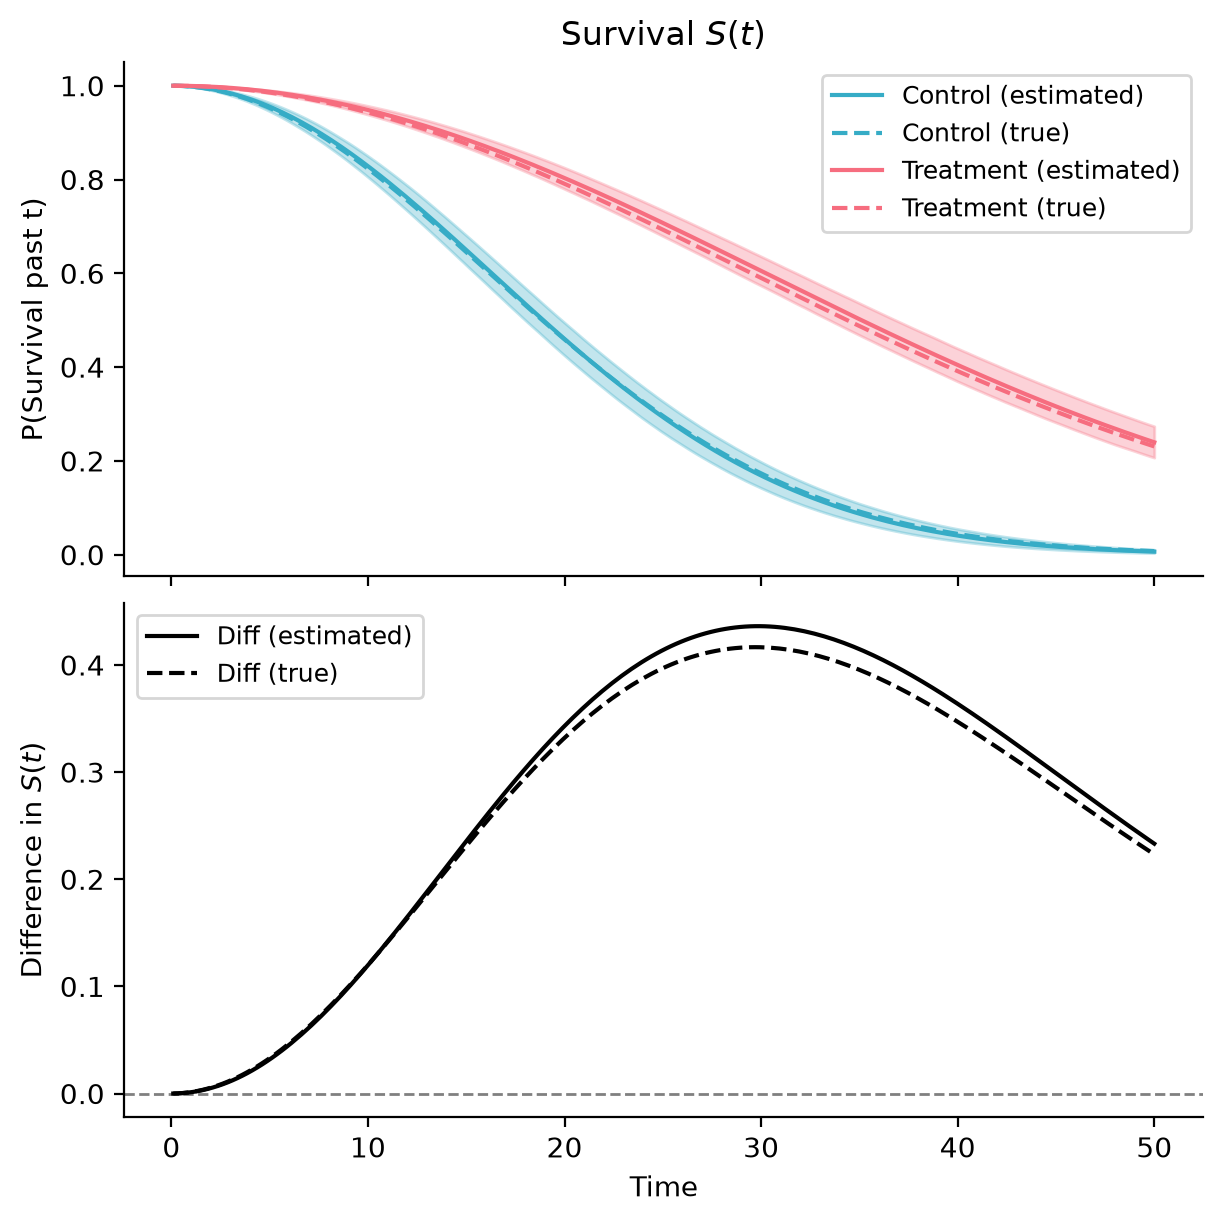

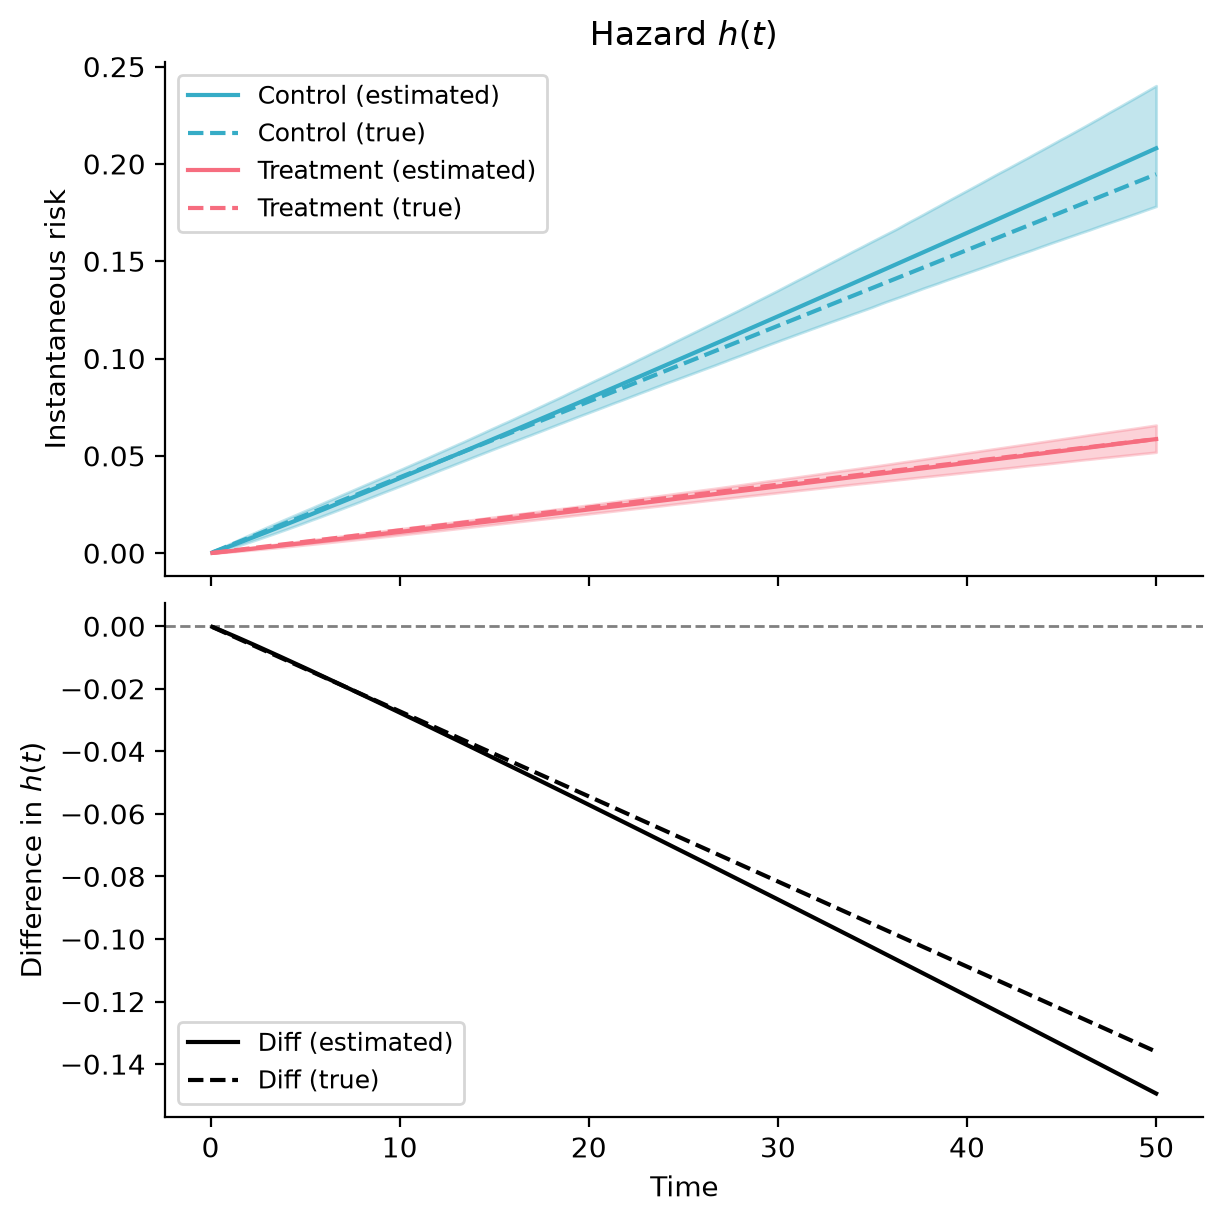

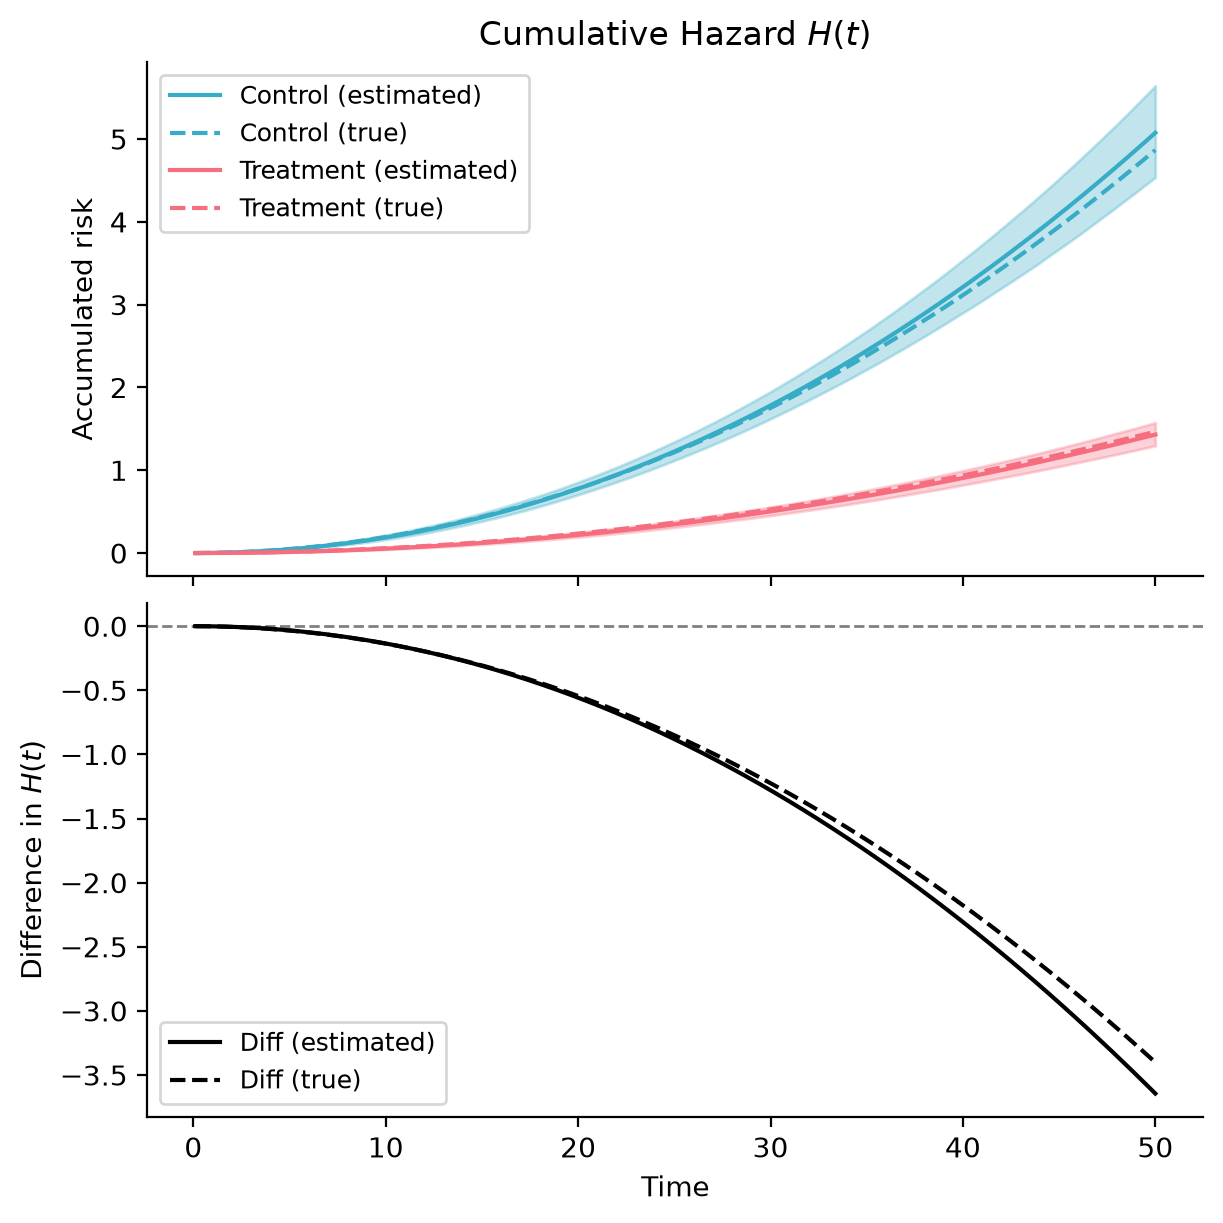

In [19]:
curve_info = [
    ("Survival $S(t)$", "P(Survival past t)", "Difference in $S(t)$"),
    ("Hazard $h(t)$", "Instantaneous risk", "Difference in $h(t)$"),
    ("Cumulative Hazard $H(t)$", "Accumulated risk", "Difference in $H(t)$"),
]

for (name, values), (title, ylabel, diff_ylabel) in zip(
    estimated_curves.items(), curve_info
):
    control_mean = values[..., 0].mean(axis=0)
    control_ci = np.percentile(values[..., 0], [2.5, 97.5], axis=0)
    control_true = true_curves[name][:, 0]

    treatment_mean = values[..., 1].mean(axis=0)
    treatment_ci = np.percentile(values[..., 1], [2.5, 97.5], axis=0)
    treatment_true = true_curves[name][:, 1]

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

    ax_top.plot(t_grid, control_mean, color="C0", label="Control (estimated)")
    ax_top.plot(t_grid, control_true, color="C0", ls="--", label="Control (true)")

    ax_top.plot(t_grid, treatment_mean, color="C1", label="Treatment (estimated)")
    ax_top.plot(t_grid, treatment_true, color="C1", ls="--", label="Treatment (true)")

    ax_top.fill_between(t_grid, control_ci[0], control_ci[1], color="C0", alpha=0.3)
    ax_top.fill_between(t_grid, treatment_ci[0], treatment_ci[1], color="C1", alpha=0.3)

    ax_top.set(title=title, ylabel=ylabel)
    ax_top.legend(loc="best", fontsize=9)

    ax_bottom.axhline(0, color="0.5", ls="--", lw=1, zorder=-1)
    ax_bottom.plot(
        t_grid,
        treatment_mean - control_mean,
        color="0",
        label="Diff (estimated)",
    )
    ax_bottom.plot(
        t_grid,
        treatment_true - control_true,
        color="0",
        ls="--",
        label="Diff (true)",
    )

    ax_bottom.set(xlabel="Time", ylabel=diff_ylabel)
    ax_bottom.legend(loc="best", fontsize=9)

The estimated curves (solid lines with shaded credible bands) closely track the true data-generating curves (dashed lines). Notice how the treatment effect manifests as a *horizontal shift*: the treated group's survival curve is displaced rightward, and their hazard curve is displaced rightward and downward. This is the AFT effect in action. The effect of changes in covariates is to stretch the time axis rather than scaling the hazard vertically.

### Approach 2: posterior predictive survival curves

The parametric approach above works beautifully when we have closed-form expressions for $S(t)$ and $\lambda(t)$. But what if we used a more complex model? Perhaps one with splines, interactions, or a distribution without clean closed forms?

An alternative is the **posterior predictive** approach. We call `model.predict(kind="response_latent")` to simulate uncensored event times for hypothetical subjects. Each posterior draw produces a simulated event time, so across all draws we get a sample of plausible event times. At each time point $t$, we estimate survival empirically as the fraction of simulated times exceeding $t$:

$$\widehat{S}_{\mathrm{pp}}(t \mid x) = \frac{1}{M} \sum_{m=1}^{M} \mathbb{I}\left(T^{(m)} > t\right).$$

This is the empirical survival function of the posterior predictive event times.

This is useful for survival models that can simulate latent event times but whose survival function is inconvenient to evaluate directly. It approximates the same posterior predictive survival probability that the closed-form method computes exactly for a Weibull model.

In [20]:
def get_posterior_predictive_survival(model, idata, t_grid, data):
    predictions = model.predict(idata, kind="response", inplace=False, data=data)
    event_time = (
        az.extract(predictions, group="predictions", var_names=["time"]).to_numpy().T
    )

    survived = event_time[:, :, np.newaxis] > t_grid[np.newaxis, np.newaxis, :]
    survival = survived.mean(axis=0)

    return {"survival": survival, "event_time": event_time}

The shape of `survival` is `(observation, time)`: one empirical survival curve for each row of `data`. This lets us use the same two-row prediction data frame, with one curve for control and one for treatment.

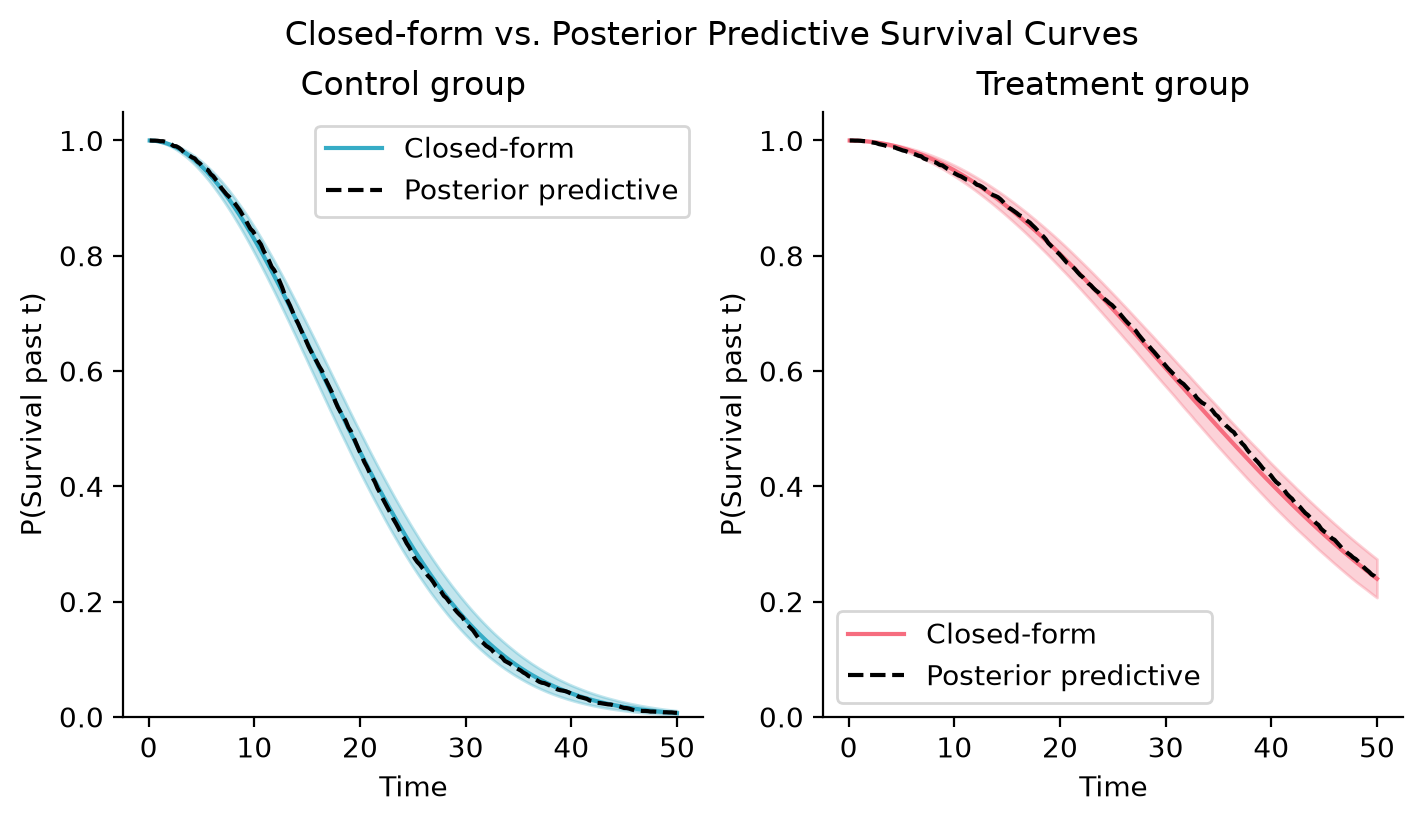

In [21]:
# | fig-cap: Comparison of closed-form and simulation-based posterior predictive survival curves. The simulation-based curves approximate the closed-form curves with Monte Carlo error.

posterior_predictive_curves = get_posterior_predictive_survival(
    model_aft, idata_aft, t_grid=t_grid, data=df_new
)

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

for ax, label, color, group in zip(
    axes, ["Control", "Treatment"], ["C0", "C1"], [0, 1]
):
    parametric_survival = estimated_curves["survival"][..., group]
    posterior_predictive_survival = posterior_predictive_curves["survival"][group]

    ax.plot(t_grid, parametric_survival.mean(axis=0), color=color, label="Closed-form")
    ax.fill_between(
        t_grid,
        *np.percentile(parametric_survival, [2.5, 97.5], axis=0),
        color=color,
        alpha=0.3,
    )

    ax.plot(
        t_grid,
        posterior_predictive_survival,
        color="black",
        linestyle="--",
        label="Posterior predictive",
    )

    ax.set(
        title=f"{label} group",
        xlabel="Time",
        ylabel="P(Survival past t)",
        ylim=(0, 1.05),
    )
    ax.legend()

fig.suptitle("Closed-form vs. Posterior Predictive Survival Curves");

The two approaches should agree closely. The closed-form curves evaluate the posterior predictive survival probability exactly for every posterior draw, whereas the simulation-based curves estimate $S(t)$ empirically from finitely many latent event-time draws. The latter is a step-function estimate, so a small left or right displacement is expected from Monte Carlo variation and diminishes as the number of simulated times grows.

::: {.callout-tip}
##### When to use which approach

For a given covariate profile, both methods target the same posterior predictive survival probability. The credible bands in the closed-form plot quantify posterior uncertainty in that probability. Simulating event times is useful when the probability cannot be evaluated directly: the empirical survival function provides its Monte Carlo approximation.

**Parametric (closed-form)**: Use when you have a standard distribution (Weibull, exponential, etc.) and want smooth, precise curves with minimal computational cost. The formulas are exact.

**Posterior predictive (`kind="response"`)**: Use when your survival model can simulate uncensored event times but its survival function is inconvenient to evaluate directly.

In practice, for a simple Weibull AFT model the closed-form approach is faster and exact. The simulation-based approach is a general fallback for suitable survival models.
:::

## Applied example: employee retention

Now let's apply these methods to a real-world problem. We'll model employee retention using a dataset tracking how long employees stayed before leaving (or being right-censored at the end of the observation window). People Analytics often has a focus on process and change dynamics. Whether we assess career trajectories in terms of time-to-promotion or time-to-attrition, we must track the development of an individual within a role, within a company and team. Understanding how these processes evolve and what factors of the time or place accelerate the outcomes is essential to organisational design and people management.

The example is borrowed from Keith McNulty's [_Handbook of Regression Modeling in People Analytics_.](https://peopleanalytics-regression-book.org/survival_analysis.html) 

### Data exploration

In our dataset we record a number of "demographic" like variables, but additionally we have surveyed each individual to record their sentiment and whether they intend to leave. These are standard measures in typical employee-engagement surveys. 

In [22]:
retention_df = pd.read_csv("data/retention.csv")

print(f"Dataset: {len(retention_df)} employees")
print(f"\nOutcome:")
print(
    f"  Left (event):      {retention_df['left'].sum()} ({100*retention_df['left'].mean():.1f}%)"
)
print(
    f"  Stayed (censored): {(1 - retention_df['left']).sum()} ({100*(1-retention_df['left'].mean()):.1f}%)"
)
print(
    f"\nTime range: {retention_df['month'].min()} to {retention_df['month'].max()} months"
)
print(f"\nCovariates:")
print(f"  Gender: {retention_df['gender'].value_counts().to_dict()}")
print(f"  Level:  {retention_df['level'].value_counts().to_dict()}")
print(f"  Field:  {retention_df['field'].nunique()} unique fields")
print(
    f"  Sentiment: {retention_df['sentiment'].min()}-{retention_df['sentiment'].max()} (continuous)"
)
print(
    f"  Intention: {retention_df['intention'].min()}-{retention_df['intention'].max()} (continuous)"
)

Dataset: 3770 employees

Outcome:
  Left (event):      1354 (35.9%)
  Stayed (censored): 2416 (64.1%)

Time range: 1 to 12 months

Covariates:
  Gender: {'M': 2603, 'F': 1167}
  Level:  {'Low': 2519, 'Medium': 787, 'High': 464}
  Field:  6 unique fields
  Sentiment: 1-10 (continuous)
  Intention: 1-10 (continuous)


The thought is that these features will appropriately stratify the population and give us insight into the risk of attrition for different types of employee. These insights should help us anticipate future needs across the various employee profiles. It is natural to think that different careers accumulate risk more or less quickly. Stresses in one position might considerably outweigh the risks in another. Some work might be seasonal or age dependent. It is insight into the factors which accelerate attrition events that we want to understand. 

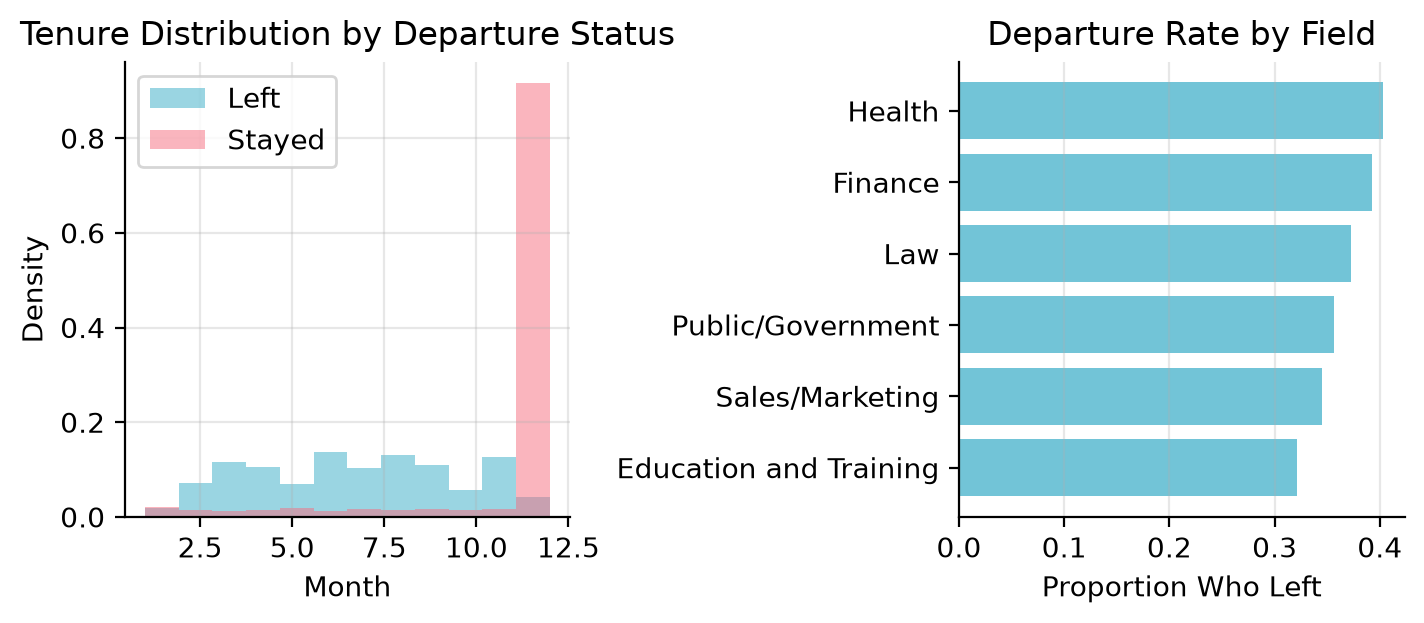

In [23]:
# | fig-cap: Distribution of tenure and departure status across employee fields

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Tenure distribution by event status
for event_val, label, color in [(1, "Left", "C0"), (0, "Stayed", "C1")]:
    subset = retention_df[retention_df["left"] == event_val]
    axes[0].hist(
        subset["month"], bins=12, alpha=0.5, density=True, label=label, color=color
    )

axes[0].set(
    xlabel="Month", ylabel="Density", title="Tenure Distribution by Departure Status"
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Event rate by field
field_rates = retention_df.groupby("field")["left"].mean().sort_values()
axes[1].barh(field_rates.index, field_rates.values, color="C0", alpha=0.7)
axes[1].set(xlabel="Proportion Who Left", title="Departure Rate by Field")
axes[1].grid(True, alpha=0.3, axis="x");

### Preparing the data

Again we need to specify the censored observations to make the data ready for modelling. 

In [24]:
# Create censoring indicator
retention_df["censoring"] = np.where(retention_df["left"] == 1, "none", "right")

### Model 1: retention Weibull AFT

We start with a Weibull AFT model including gender, seniority level, field, employee sentiment, and intention to leave as predictors.

In [25]:
formula_base = (
    "censored(month, censoring) ~ gender + level + field + sentiment + intention"
)

model_weibull = bmb.Model(formula_base, data=retention_df, family="weibull", link="log")
idata_weibull = model_weibull.fit(random_seed=seed)

NUTS[nutpie]: [alpha, gender, level, field, sentiment, intention, Intercept_centered]


Output()

In [26]:
az.summary(idata_weibull)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gender[M],-0.0089,0.034,-0.065,0.045,5692,3108,1.00,0.00046,0.00052
level[Low],-0.102,0.053,-0.19,-0.019,3240,2789,1.00,0.00094,0.00076
level[Medium],-0.07,0.061,-0.17,0.025,3237,2721,1.00,0.0011,0.00091
field[Finance],-0.152,0.04,-0.21,-0.088,4000,3296,1.00,0.00063,0.00057
field[Health],-0.151,0.078,-0.27,-0.023,5308,3563,1.00,0.0011,0.0012
field[Law],-0.042,0.085,-0.17,0.099,5134,3082,1.00,0.0012,0.0013
field[Public/Government],-0.081,0.054,-0.17,0.0041,4999,3302,1.00,0.00076,0.00085
field[Sales/Marketing],-0.065,0.062,-0.16,0.036,5171,3235,1.00,0.00086,0.00097
sentiment,0.0183,0.009,0.0042,0.033,5719,3208,1.00,0.00012,0.00014
intention,-0.1233,0.0083,-0.14,-0.11,4868,3636,1.00,0.00012,0.00012


::: {.callout-note}
## Reading the retention coefficients

Since this is an AFT model:

- **Positive coefficients** mean *longer retention* (the employee stays longer)
- **Negative coefficients** mean *shorter retention* (the employee leaves sooner)
- `sentiment` and `intention` are on their original scales, so a one-unit increase in sentiment has the indicated effect on log-time

For example, if the sentiment coefficient is positive, higher job satisfaction is associated with longer tenure. The employee's "survival time" in the role is stretched or contracted as expectation for the role demands.
:::

### Model 2: exponential AFT

In [27]:
model_exp_ret = bmb.Model(
    formula_base, data=retention_df, family="exponential", link="log"
)
idata_exp_ret = model_exp_ret.fit(random_seed=seed)

NUTS[nutpie]: [gender, level, field, sentiment, intention, Intercept_centered]


Output()

In [28]:
az.summary(idata_exp_ret)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gender[M],-0.016,0.059,-0.11,0.079,5158,2967,1.00,0.00083,0.00096
level[Low],-0.161,0.091,-0.31,-0.017,3256,2763,1.00,0.0016,0.0014
level[Medium],-0.11,0.103,-0.27,0.051,3334,3095,1.00,0.0018,0.0015
field[Finance],-0.237,0.066,-0.34,-0.13,4076,3338,1.00,0.001,0.00091
field[Health],-0.235,0.13,-0.44,-0.023,4587,3062,1.00,0.0019,0.0019
field[Law],-0.072,0.148,-0.31,0.17,4989,3295,1.00,0.0021,0.0022
field[Public/Government],-0.118,0.088,-0.26,0.02,4475,3057,1.00,0.0013,0.0014
field[Sales/Marketing],-0.104,0.106,-0.27,0.065,4850,3328,1.00,0.0015,0.0015
sentiment,0.0286,0.0148,0.0056,0.053,5545,3284,1.00,0.0002,0.00021
intention,-0.1893,0.0132,-0.21,-0.17,4787,3428,1.00,0.00019,0.00022


Showing similar coefficient estimates. 

### Model 3: Weibull AFT with frailty (random effects)

Employees in different fields may share unobserved characteristics that affect retention, organizational culture, industry norms or career mobility patterns. A **frailty model** captures this by adding a random effect (random intercept) for field. This is the survival-analysis equivalent of a random-intercept multilevel model.

The frailty term absorbs unobserved heterogeneity between fields that isn't captured by the fixed effect of field alone. It also provides partial pooling: fields with fewer observations borrow strength from the overall distribution, leading to more stable estimates.

In [29]:
formula_frailty = (
    "censored(month, censoring) ~ gender + level + sentiment + intention + (1|field)"
)
model_frailty = bmb.Model(
    formula_frailty, data=retention_df, family="weibull", link="log", noncentered=False
)
idata_frailty = model_frailty.fit(random_seed=seed)

NUTS[nutpie]: [alpha, gender, level, sentiment, intention, Intercept_centered, 1|field_sigma, 1|field]


Output()

In [30]:
az.summary(idata_frailty)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gender[M],-0.0107,0.036,-0.066,0.045,5881,2845,1.00,0.00047,0.00066
level[Low],-0.101,0.054,-0.19,-0.016,2582,2482,1.00,0.0011,0.00076
level[Medium],-0.07,0.06,-0.17,0.024,2496,2549,1.00,0.0012,0.00089
sentiment,0.0183,0.0091,0.0042,0.033,5338,3281,1.00,0.00012,0.00015
intention,-0.1229,0.0083,-0.14,-0.11,4228,3612,1.00,0.00013,0.00013
Intercept_centered,2.818,0.049,2.7,2.9,832,1055,1.00,0.0018,0.0025
1|field[Education and Training],0.069,0.052,0.0004,0.15,984,1113,1.00,0.0019,0.0026
1|field[Finance],-0.056,0.05,-0.13,0.016,901,1011,1.00,0.0018,0.0023
1|field[Health],-0.033,0.062,-0.14,0.062,1698,2009,1.00,0.0016,0.0016
1|field[Law],0.018,0.064,-0.076,0.12,1810,1524,1.00,0.0016,0.002


Here we see the estimated posterior parameterisation of the random effects model. The rank order and direction of the coefficients by field are generally a useful way to assess risk of attrition. Additionally, the `1|field_sigma` parameter is useful to check the degree of variability in field specific effects. 

### Model comparison

In [31]:
model_weibull.compute_log_likelihood(idata_weibull)
model_exp_ret.compute_log_likelihood(idata_exp_ret)
model_frailty.compute_log_likelihood(idata_frailty)

compare_retention = az.compare(
    {
        "Weibull": idata_weibull,
        "Exponential": idata_exp_ret,
        "Weibull + Frailty": idata_frailty,
    },
)

compare_retention

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Weibull + Frailty,0,0.0,0.00,NaN,,,11.1,-5500.0,87.0,1.0
Weibull,1,-1.0,0.91,0.88,|elpd_diff| < 4,,12.6,-5500.0,87.0,0.0
Exponential,2,-190.0,15.00,1.00,,,10.0,-5700.0,92.0,0.0


With the comparison of models we see that the random effects weibull model is to be preferred over the two alternatives. 

### Retention survival curves by field

Let's put the survival curve machinery to work on the retention data. We use the posterior predictive approach here and pass in a DataFrame with the desired covariate profile and let the model simulate survival times for this individual. The EDA above showed that departure rates vary meaningfully across fields. Let's see whether the fitted Weibull model captures these differences as distinct survival curves.

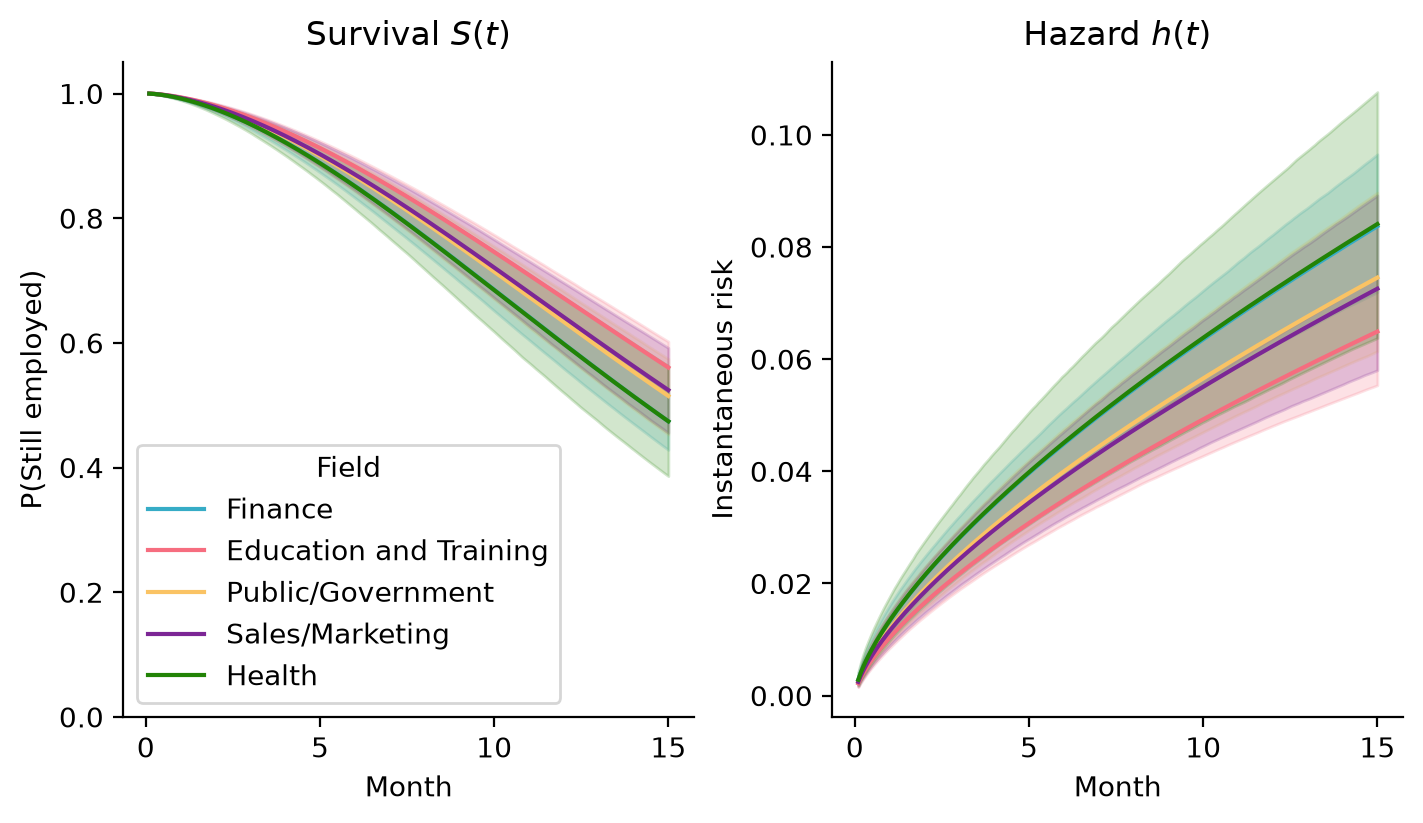

In [32]:
t_grid = np.linspace(0.1, 15, 200)
fields_to_plot = [
    "Finance",
    "Education and Training",
    "Public/Government",
    "Sales/Marketing",
    "Health",
]

retention_profiles = pd.DataFrame(
    {
        "gender": "F",
        "level": "Low",
        "field": fields_to_plot,
        "sentiment": retention_df["sentiment"].median(),
        "intention": retention_df["intention"].median(),
    }
)
retention_curves = get_estimated_curves_weibull(
    model_weibull, idata_weibull, t_grid=t_grid, data=retention_profiles
)

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

for ax, (name, values) in zip(axes, retention_curves.items()):
    for index, field in enumerate(fields_to_plot):
        curve = values[..., index]
        ax.plot(t_grid, curve.mean(axis=0), color=f"C{index}", label=field)
        ax.fill_between(
            t_grid,
            *np.percentile(curve, [2.5, 97.5], axis=0),
            color=f"C{index}",
            alpha=0.2,
        )

axes[0].set(
    title="Survival $S(t)$", xlabel="Month", ylabel="P(Still employed)", ylim=(0, 1.05)
)
axes[1].set(title="Hazard $h(t)$", xlabel="Month", ylabel="Instantaneous risk")
axes[0].legend(title="Field", fontsize=10);

These curves translate the AFT coefficients into directly interpretable predictions. For an employee with median sentiment and intention scores, what is their probability of still being employed at month $t$? Fields with higher departure rates in the raw data produce lower survival curves here. The survival curves differ across fields, what does that tell us about how attrition accumulates differently? Is it front-loaded (new employees leave quickly or not at all)? Is it gradual (risk builds with tenure)? The Weibull parametric model of our hazard forces the accumulation to be monotonic, but the career paths show sharply different patterns of accumulating risk.

### Understanding the coefficients across models

A retention model like this is most useful when HR needs to prioritize interventions. If the model shows that sentiment is a stronger predictor than seniority level, that argues for investing in engagement programs rather than promotion pipelines. If field-level random effects are large, it suggests that retention is partly a team/culture problem, not just an individual one. Consequently, any interventions should target organizational units rather than individuals.

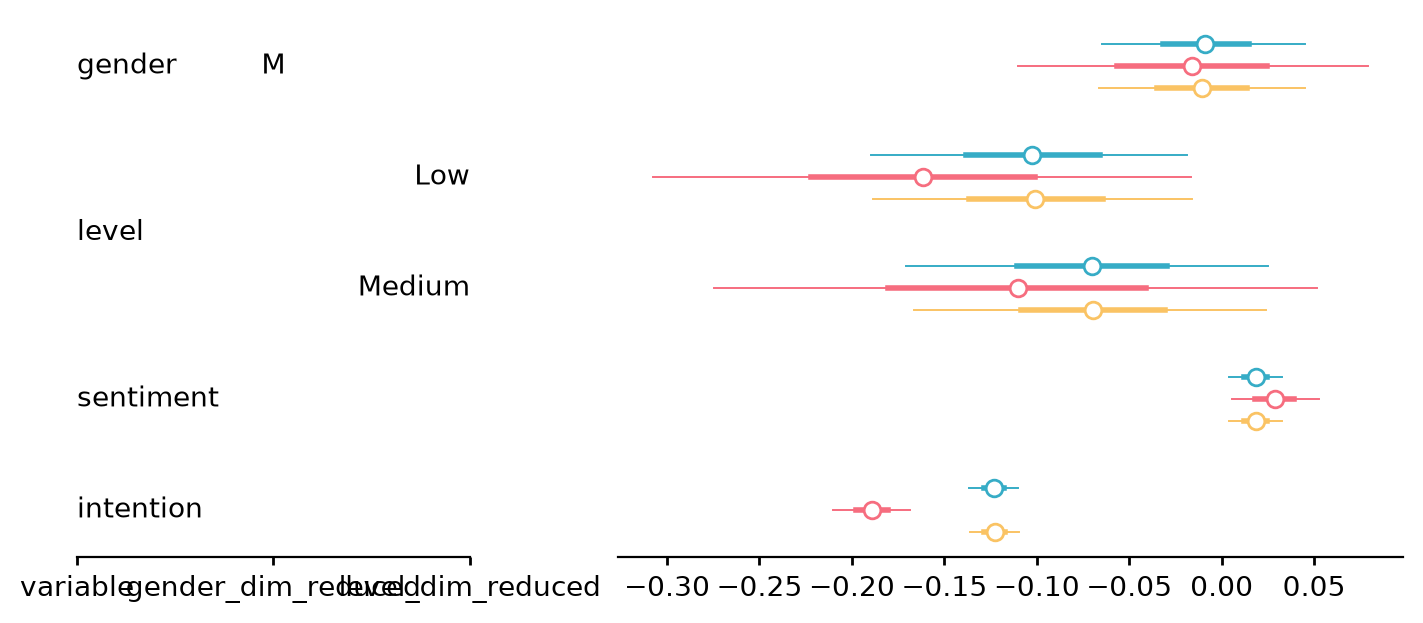

In [33]:
# | fig-cap: Fixed-effect estimates across the three retention models.

az.plot_forest(
    {
        "Weibull": idata_weibull,
        "Exponential": idata_exp_ret,
        "Weibull + Frailty": idata_frailty,
    },
    var_names=["gender", "level", "sentiment", "intention"],
    combined=True,
    figure_kwargs={"figsize": (7, 3)},
);

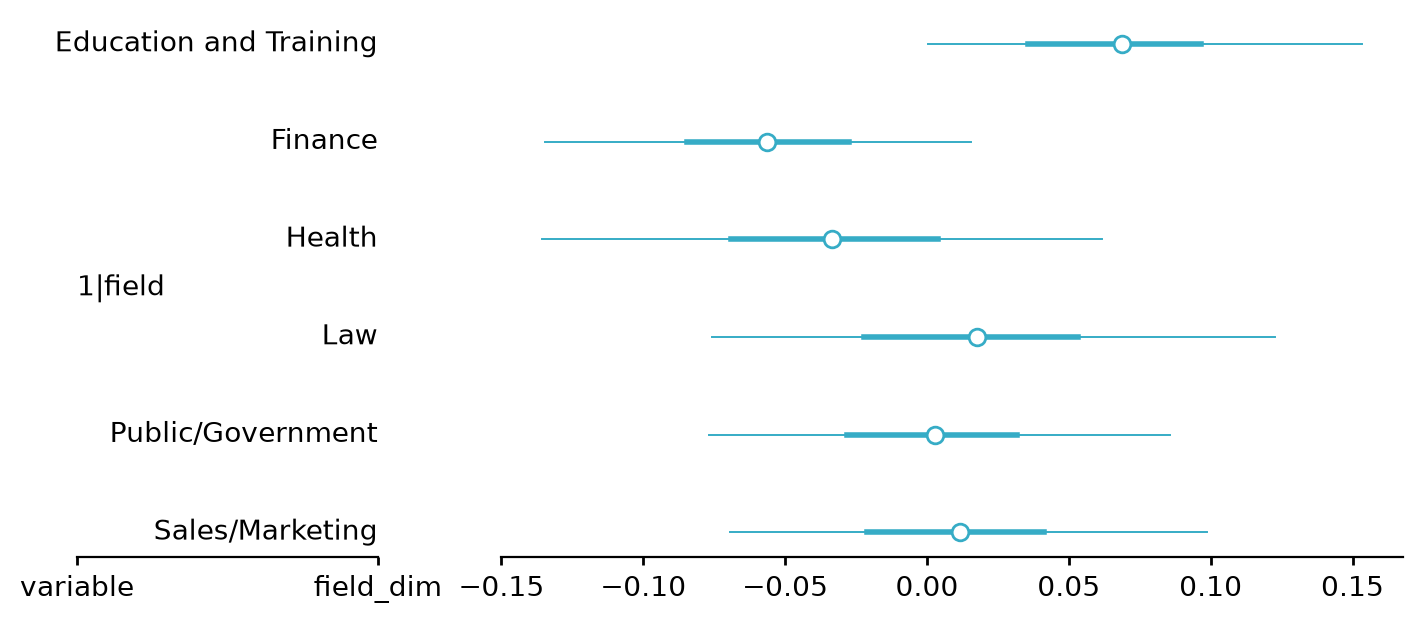

In [34]:
# | fig-cap: Field random-effect estimates from the Weibull frailty model.

az.plot_forest(
    {"Weibull + Frailty": idata_frailty},
    var_names=["1|field"],
    combined=True,
    figure_kwargs={"figsize": (7, 3)},
);

Here we've plotted the parameters derived across each model and pulled out the random effects for each field. This shows the stability of the fixed effects on `sentiment` across the three models, but demonstrates how the exponential model shows a more extreme effect on the `intention` covariate. This suggests that the exponential with the constant hazard is compensating for its inflexiblity by placing extra weight on the `intention` parameter, but the direction of the effect is the same. The stronger the stated intention to leave, the more likely we see departures. 

For the frailty terms we see how `Education and Training` has a positive effect on the accelerated time, this suggests increased tenure within these fields over the baseline. This is plausibly related to vocational nature of these jobs and the limited outside options. `Health` and `Finance` also show directional effects but in the opposite direction, where there are plausibly more outside offers and more cut-throat business practices. This speeds up time-to-departure rather than reduces it. We can also see how the other industry random effects tend to hover around 0 suggesting minor to negligible modifications of the baseline expectation due to the partial pooling of our hierarchical model. 

::: {.callout-tip}
##### When to use frailty models

Frailty models are most useful when:

- You have **grouped data** with potential cluster-level heterogeneity (e.g., patients within hospitals, employees within departments)
- The number of groups is **moderate to large** (5+ groups) but group sizes may vary
- You want **partial pooling**: groups with fewer observations are shrunk toward the grand mean, borrowing strength from the overall distribution
- You want to account for **unobserved confounders** that vary across groups

They are less useful when you have very few groups (a fixed effect may be more appropriate) or when between-group variation is negligible.
:::

## Beyond the Weibull: alternative parametric families

So far we've relied on the Weibull (and its special case, the exponential) for all our continuous-time models. The Weibull is a powerful default, but it enforces a **monotonic hazard**. Real-world processes often have non-monotonic risk profiles: surgical recovery risk peaks in the first days then declines, employee attrition may spike early and then stabilize, and disease relapse can follow a hump-shaped pattern.

In this section we fit **log-normal** and **log-logistic** models to the same simulated data and compare how the choice of distributional family shapes the estimated hazard and survival curves. This highlights a fundamental feature of continuous-time parametric models: your distributional assumption is a substantive claim about the shape of risk over time, not just a technical convenience.

Bambi provides both distributions as built-in families: `family="lognormal"` and `family="loglogistic"`. Both work with Bambi's `censored()` response for continuous-time survival models.
Below we fit both built-in families.

### Log-normal

The **log-normal** distribution arises when $\log(T)$ is normally distributed. Its key properties for survival analysis:

- **Non-monotonic hazard**: The hazard rises initially, reaches a peak, then declines toward zero. This makes it suitable for processes where risk increases early on but diminishes for long-term survivors. For example, you can think of recovery times from surgery, or time to relapse for certain cancers.
- **AFT only**: The log-normal does not satisfy the proportional-hazards assumption, so coefficients have only the AFT (time ratio) interpretation.
- **Heavier right tail** than the Weibull, which can be appropriate when some subjects survive much longer than the bulk.

Bambi includes this family directly:

In [35]:
model_lognorm = bmb.Model(
    "censored(time, censoring) ~ treatment + age",
    data=df,
    family="lognormal",
)

idata_lognormal = model_lognorm.fit(random_seed=seed)
model_lognorm.compute_log_likelihood(idata_lognormal)

NUTS[nutpie]: [sigma, treatment, age, Intercept_centered]


Output()

In [36]:
az.summary(idata_lognormal, var_names=["Intercept", "treatment", "age", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.8334,0.0284,2.8,2.9,7625,3415,1.00,0.00033,0.00044
treatment,0.6616,0.041,0.6,0.73,7335,3592,1.00,0.00048,0.00064
age,-0.4689,0.0203,-0.5,-0.44,7355,2896,1.00,0.00024,0.00032
sigma,0.6235,0.0147,0.6,0.65,7516,2958,1.00,0.00017,0.00023


### Log-logistic

The **log-logistic** distribution arises when $\log(T)$ follows a logistic distribution. It shares several features with the log-normal but has some distinct advantages:

- **Non-monotonic hazard**: Like the log-normal, the hazard can rise and then fall, but the log-logistic has a closed-form survival function $S(t) = 1/(1 + (t/\sigma)^{1/\alpha})$, which makes computation simpler.
- **AFT only**: No proportional hazards representation.
- **Proportional odds**: The log-logistic is the only common survival distribution that satisfies the **proportional odds** assumption, which can be useful when odds ratios are the natural estimand.
- **Common in economics and social science**: Often used for modelling duration data (unemployment spells, time to adoption of a technology) where the hazard is hump-shaped.

In [37]:
model_loglogistic = bmb.Model(
    "censored(time, censoring) ~ treatment + age",
    data=df,
    family="loglogistic",
    priors={"alpha": bmb.Prior("HalfNormal", sigma=1)},
)

idata_loglogistic = model_loglogistic.fit(random_seed=seed)
model_loglogistic.compute_log_likelihood(idata_loglogistic)

NUTS[nutpie]: [alpha, treatment, age, Intercept_centered]


Output()

In [38]:
az.summary(idata_loglogistic, var_names=["Intercept", "treatment", "age", "alpha"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.8785,0.026,2.8,2.9,7076,3229,1.00,0.00031,0.00041
treatment,0.6398,0.037,0.58,0.7,6965,3386,1.00,0.00044,0.00058
age,-0.4663,0.0195,-0.5,-0.44,7403,3284,1.00,0.00023,0.0003
alpha,0.343,0.0097,0.33,0.36,7431,3659,1.00,0.00011,0.00014


### Comparing parametric families

Having fit Weibull, log-normal, and log-logistic models to the same data, we can now visualize how these distributional assumptions shape the estimated hazard and survival curves. Each family imposes a different structural constraint on the hazard:

- **Weibull**: Yields a monotonic hazard, either always increasing, always decreasing, or constant. Determined by a single shape parameter.
- **Log-normal**: Hump-shaped hazard. Rises to a peak then declines toward zero. Appropriate when long-term survivors face diminishing risk.
- **Log-logistic**: Also hump-shaped, but with heavier tails than the log-normal. The hazard declines more slowly, reflecting sustained (though decreasing) risk.

The plot below shows all three fitted models for the baseline profile (control group, average age), with 94% credible intervals. Differences between the curves reflect the structural assumptions of each family, not just statistical uncertainty.

In [39]:
# | code-fold: true


def get_lognormal_curves(model, idata, t_grid, data):
    predictions = model.predict(idata, kind="response_params", inplace=False, data=data)
    mu = az.extract(predictions, group="predictions", var_names=["mu"]).to_numpy().T

    mu = mu[:, np.newaxis]
    t_grid = t_grid[np.newaxis, :, np.newaxis]

    sigma = az.extract(idata, var_names=["sigma"]).to_numpy()[:, np.newaxis, np.newaxis]
    distribution = pz.LogNormal(mu=mu, sigma=sigma)

    survival = distribution.sf(t_grid)
    hazard = distribution.pdf(t_grid) / survival

    return {"survival": survival, "hazard": hazard}


def get_loglogistic_curves(model, idata, t_grid, data):
    predictions = model.predict(idata, kind="response_params", inplace=False, data=data)
    mu = az.extract(predictions, group="predictions", var_names=["mu"]).to_numpy().T

    mu = mu[:, np.newaxis]
    t_grid = t_grid[np.newaxis, :, np.newaxis]

    alpha = az.extract(idata, var_names=["alpha"]).to_numpy()[:, np.newaxis, np.newaxis]
    distribution = pz.LogLogistic(alpha=np.exp(mu), beta=1 / alpha)

    survival = distribution.sf(t_grid)
    hazard = distribution.pdf(t_grid) / survival

    return {"survival": survival, "hazard": hazard}

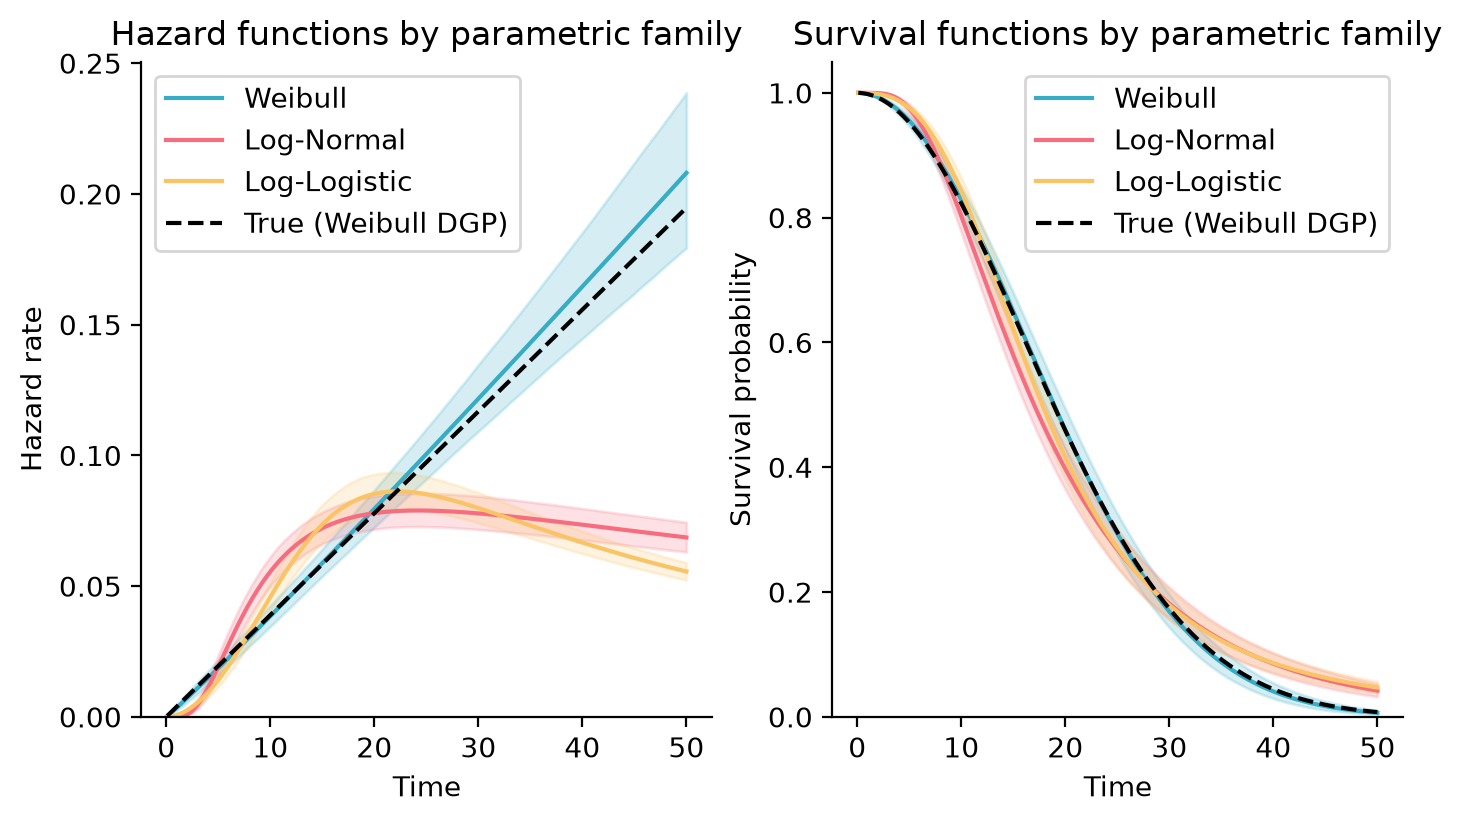

In [40]:
# | code-fold: true
# | fig-cap: Hazard and survival curves from three parametric families fitted to the same data. Differences reflect distributional assumptions about hazard shape.

t_compare = np.linspace(0.1, 50, 300)
df_compare = pd.DataFrame({"treatment": [0], "age": [0.0]})

estimated_curves = {
    "Weibull": get_estimated_curves_weibull(
        model_aft, idata_aft, t_compare, df_compare
    ),
    "Log-Normal": get_lognormal_curves(
        model_lognorm, idata_lognormal, t_compare, df_compare
    ),
    "Log-Logistic": get_loglogistic_curves(
        model_loglogistic, idata_loglogistic, t_compare, df_compare
    ),
}

true_curves = get_true_curves_weibull(
    intercept_true, beta_treatment, beta_age, shape_true, t_compare, df_compare
)

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

family_colors = {"Weibull": "C0", "Log-Normal": "C1", "Log-Logistic": "C2"}

for family, color in family_colors.items():
    hazard = estimated_curves[family]["hazard"][..., 0]
    hazard_mean = hazard.mean(axis=0)
    hazard_interval = np.percentile(hazard, [3, 97], axis=0)
    axes[0].plot(t_compare, hazard_mean, color=color, label=family)
    axes[0].fill_between(
        t_compare, hazard_interval[0], hazard_interval[1], color=color, alpha=0.2
    )

    survival = estimated_curves[family]["survival"][..., 0]
    survival_mean = survival.mean(axis=0)
    survival_interval = np.percentile(survival, [3, 97], axis=0)
    axes[1].plot(t_compare, survival_mean, color=color, label=family)
    axes[1].fill_between(
        t_compare, survival_interval[0], survival_interval[1], color=color, alpha=0.2
    )

axes[0].plot(t_compare, true_curves["hazard"][:, 0], "k--", label="True (Weibull DGP)")
axes[1].plot(
    t_compare, true_curves["survival"][:, 0], "k--", label="True (Weibull DGP)"
)
axes[0].set(
    xlabel="Time", ylabel="Hazard rate", title="Hazard functions by parametric family"
)
axes[1].set(
    xlabel="Time",
    ylabel="Survival probability",
    title="Survival functions by parametric family",
)
axes[0].legend()
axes[1].legend()

axes[0].set_ylim(bottom=0)
axes[1].set_ylim(0, 1.05);

The black dashed line shows the true data-generating process (a Weibull). The hazard panel is the most revealing: the Weibull fit tracks the true monotonically increasing hazard closely, while the log-normal and log-logistic impose a hump-shaped hazard that peaks and then declines. These models should show a structural mismatch with the DGP. Comparing models on LOO will favor the Weibull: not because it has more parameters, but because its structural assumption happens to match reality.

The survival panel shows that all three models broadly agree on the overall survival trajectory, which makes sense because they're fitting the same data, after all. But they diverge in the tails, where the structural assumptions matter most and data is sparsest. The log-normal and log-logistic overestimate survival at late times because their declining hazards imply a slower accumulation of risk than the true DGP.

We can also formally compare model fit using LOO:

In [41]:
comparison = az.compare(
    {
        "Weibull": idata_aft,
        "LogNormal": idata_lognormal,
        "LogLogistic": idata_loglogistic,
    }
)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
Weibull,0,0.0,0.0,NaN,,,4.2,-3600.0,33.0,0.89
LogLogistic,1,-30.0,8.4,1.0,,,4.0,-3630.0,36.0,0.00
LogNormal,2,-50.0,14.0,1.0,,,4.8,-3650.0,38.0,0.11


## Competing risks: when multiple processes accumulate simultaneously

The survival models we've built so far assume a single risk process i.e. one cause, one accumulating hazard, one event. But many real phenomena involve multiple, simultaneous risk processes each pushing toward their own distinct endpoint.

Consider a clinical trial tracking cardiovascular mortality. At any moment a patient is not only accumulating cardiovascular risk but also non-cardiovascular risk and perhaps infection, cancer or organ failure too. These processes run in parallel, and crucially, they *compete*: a patient who dies from non-cardiovascular causes is no longer at risk of cardiovascular death. Treating non-cardiovascular deaths as simple censoring without controlling for this other risk category is a naive single-cause approach. It implicitly assumes these other risks they tell us nothing about cardiovascular risk. But that is only valid if the two processes are unrelated, which in practice they rarely are.

This is the competing risks problem: an individual faces $K$ distinct risk processes accumulating simultaneously, and we observe whichever event fires first. The statistical challenge is that each cause's hazard contributes to the probability of *surviving long enough to experience any event at all*. The overall survival function is not determined by any single cause in isolation, it is determined by the sum of all competing cumulative hazards:

$$S(t) = \exp\!\left(-\sum_{k=1}^{K} H_k(t)\right)$$

This has a direct consequence for the likelihood. When we observe individual $i$ still alive at time $t_i$, that survival reflects the joint action of all $K$ hazards, not just the one they eventually succumb to (or would have, had observation continued). Every individual informs every cause's hazard through this shared survival term, even accounting for censored individuals.

The **Cumulative Incidence Function (CIF)** for cause $k$ captures this properly:

$$F_k(t) = \int_0^t h_k(s) \cdot S(s) \, ds$$

This is *not* simply $1 - S_k(t)$ from a cause-specific survival model. It is the probability of failing from cause $k$ before time $t$, accounting for the fact that competing causes may remove individuals from the risk set first. Summing CIFs across all causes and adding the overall survival gives back 1 at every time point gives us a coherent probability partition across the risk categories.

$$\sum_{k=1}^{K} F_k(t) + S(t) = 1$$

The Weibull competing risks model below encodes this structure directly in the likelihood. Two linear predictors, one per cause, feed into a single joint log-likelihood where both causes' hazards appear in every observation's survival contribution.

Let's set up the data generating process:

In [42]:
# 1. DATA GENERATING PROCESS (Weibull competing risks)
n = 2_000

age = rng.normal(65, 10, n)
sex = rng.binomial(1, 0.5, n).astype(float)
treatment = rng.binomial(1, 0.5, n)
age_c = age - 65

TRUE = {
    # Cause 1
    "intercept_1": -3.5,
    "age_c_1": 0.03,
    "sex_1": 0.50,
    "trt_1": -1.00,
    "alpha1": 1.5,  # Weibull shape
    # Cause 2
    "intercept_2": -4.2,
    "age_c_2": 0.02,
    "sex_2": -0.30,
    "trt_2": 0.00,
    "alpha2": 1.2,  # Weibull shape
}

mu1 = (
    TRUE["intercept_1"]
    + TRUE["age_c_1"] * age_c
    + TRUE["sex_1"] * sex
    + TRUE["trt_1"] * treatment
)

mu2 = (
    TRUE["intercept_2"]
    + TRUE["age_c_2"] * age_c
    + TRUE["sex_2"] * sex
    + TRUE["trt_2"] * treatment
)

H1 = np.exp(mu1)
H2 = np.exp(mu2)

alpha1 = TRUE["alpha1"]
alpha2 = TRUE["alpha2"]

# ---- Simulate latent Weibull times ----
u1 = rng.uniform(size=n)
u2 = rng.uniform(size=n)

T1 = (-np.log(u1) / H1) ** (1.0 / alpha1)
T2 = (-np.log(u2) / H2) ** (1.0 / alpha2)

t_event = np.minimum(T1, T2)
cause = np.where(T1 < T2, 1, 2)

# ---- Random right censoring ----
C = rng.uniform(0, 25, size=n)
time = np.minimum(t_event, C)
status = np.where(t_event <= C, "event", "right")
cause = np.where(t_event <= C, np.where(cause == 1, "cv_death", "noncv_death"), "none")

df = pd.DataFrame(
    {
        "time": time,
        "status": status,
        "cause": cause,
        "age_c": age_c,
        "sex": sex,
        "treatment": np.where(treatment == 1, "B", "A"),
    }
)

print("Event counts:")
print(df.loc[df["status"] == "event", "cause"].value_counts())
print(f"Censoring rate: {(status == "right").mean():.1%}")

Event counts:
cause
cv_death       984
noncv_death    263
Name: count, dtype: int64
Censoring rate: 37.6%


Bambi provides competing-risks models through the built-in `risks()` response transformation for the `exponential`, `weibull`, `lognormal`, `loglogistic`, `gamma`, and `wald` survival families. The transformation receives the observed time, an event status (`"event"` or `"right"`), and a cause column. The selected family estimates a separate set of distributional parameters for every cause and combines their survival contributions in one joint likelihood.

In [43]:
# | code-fold: true
priors = {
    # These priors are applied independently to each cause.
    "Intercept": bmb.Prior("Normal", mu=2.5, sigma=2),
    "age_c": bmb.Prior("Normal", mu=0, sigma=0.5),
    "sex": bmb.Prior("Normal", mu=0, sigma=1),
    "treatment": bmb.Prior("Normal", mu=0, sigma=1),
    "alpha": bmb.Prior("LogNormal", mu=0, sigma=0.5),
}

model = bmb.Model(
    "risks(time, status, cause) ~ age_c + sex + treatment",
    data=df,
    family="weibull",
    link="log",
    priors=priors,
)

idata = model.fit(target_accept=0.9, random_seed=seed)

NUTS[nutpie]: [alpha, age_c, sex, treatment, Intercept_centered]


Output()

#### The Pattern of Competing Risks Likelihoods

`risks(time, status, cause)` registers all three response columns as Bambi data containers. `status` distinguishes observed events from right-censored observations, while `cause` identifies the event type. Bambi maps the event causes to one-based integer codes internally; censored observations have cause code zero and contribute only the joint survival probability.

The built-in likelihood combines a cause-specific density for each observed event with the survival probabilities for every other cause. Thus every observation, including censored ones, informs every cause-specific process through the shared survival term. This is the statistical core of competing risks: surviving to time $t$ means not yet having succumbed to *any* cause.

With a Weibull family, each cause receives its own mean and shape parameters. The built-in competing-risks implementation uses one common parametric family across causes, but the covariate effects and distributional parameters are cause-specific.

#### Competing Risks and Bambi

Once we've established the risks of interest, we can pass them directly through Bambi's formula interface. A single formula gives each cause its own Weibull parameters and regression coefficients. `age_c`, `sex`, and `treatment` may therefore accelerate or decelerate each cause differently, while the model still estimates their joint survival process.

Estimating the model yields the familiar posterior. To compute cumulative incidence functions, `predict(kind="time_and_cause")` simulates the first-event time and its cause for every posterior draw. The CIF is then the posterior predictive proportion of simulations that have experienced each cause by a given time.

In [44]:
az.summary(idata)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
age_c[cv_death],-0.0185,0.00203,-0.022,-0.015,6092,3112,1.00,2.6e-05,3.3e-05
age_c[noncv_death],-0.0167,0.0052,-0.025,-0.0086,6562,2637,1.00,6.4e-05,0.0001
sex[cv_death],-0.291,0.043,-0.36,-0.22,6619,3356,1.00,0.00053,0.0007
sex[noncv_death],0.245,0.108,0.074,0.42,5475,3166,1.00,0.0015,0.0019
"treatment[B, cv_death]",0.74,0.045,0.67,0.81,5716,3371,1.00,0.0006,0.00068
"treatment[B, noncv_death]",-0.212,0.112,-0.39,-0.033,4237,3261,1.00,0.0017,0.0018
Intercept_centered[cv_death],2.4209,0.0241,2.4,2.5,5103,3272,1.00,0.00034,0.00036
Intercept_centered[noncv_death],3.666,0.105,3.5,3.8,1506,1936,1.00,0.0027,0.0018
alpha[cv_death],1.4862,0.037,1.4,1.5,6197,3517,1.00,0.00047,0.00054
alpha[noncv_death],1.196,0.06,1.1,1.3,1614,2042,1.00,0.0015,0.00096


### Cumulative incidence functions

However, the natural inferential target is not the regression coefficients themselves but the **Cumulative Incidence Function (CIF)** i.e. the probability that an individual has experienced a specific cause of failure by time $t$, given their covariate profile. 

The CIF is the right quantity to report in a competing risks analysis for a subtle but important reason. The intuitive alternative of computing $1 - S_k(t)$ from a cause-specific survival model will overstate the risk of each individual cause. It implicitly asks: *what is the probability of CV death by time $t$ in a world where non-CV death does not exist?* That is not a useful clinical or policy question. Patients do not live in worlds where competing causes have been eliminated.

The CIF instead asks: *what is the probability of CV death by time $t$ in the real world, where the patient is simultaneously at risk of dying from other causes?* Formally:

$$F_k(t \mid \mathbf{x}) = \int_0^t h_k(s \mid \mathbf{x}) \cdot S(s \mid \mathbf{x}) \, ds$$

The joint survival term $S(s)$ inside the integral is doing the key work. It discounts the incidence of cause $k$ at each moment $s$ by the probability of having survived all causes up to that point. A patient who is likely to die early from a competing cause accumulates less incidence from the primary cause — not because their cause-specific hazard is lower, but because they are less likely to be alive and at risk.

This disentanglement matters practically. Suppose treatment B dramatically reduces CV mortality. In a naive single-cause analysis, this might appear to slightly *increase* non-CV mortality. The increase seems paradoxical if you expect the treatment to help, but consider how patients now live long enough to experience non-CV events they would previously never have reached. The CIFs make this transparent: CV incidence falls, non-CV incidence rises mechanically as a consequence, and the overall survival improvement is visible in both panels simultaneously.

Three properties make CIFs the preferred reporting standard in competing risks analyses:

**Coherent probability accounting.** The CIFs and the overall survival partition the probability space exhaustively at every time point: $\sum_k F_k(t) + S(t) = 1$. You can read off, for any covariate profile and any time horizon, the probability of each outcome.

**Sensitivity to both hazards.** Because both $h_1$ and $h_2$ enter the survival term, the CIF for cause 1 responds to changes in the cause-2 hazard even when cause-2 coefficients are held fixed. This captures the real-world substitution between competing risks.

**Direct policy relevance.** In clinical trials, the CIF answers the question clinicians and patients actually care about: *given this treatment and this patient profile, what is the probability of this specific bad outcome within five years?* The cause-specific hazard ratio is a mechanistic quantity; the CIF is an absolute risk quantity grounded in real-world incidence.

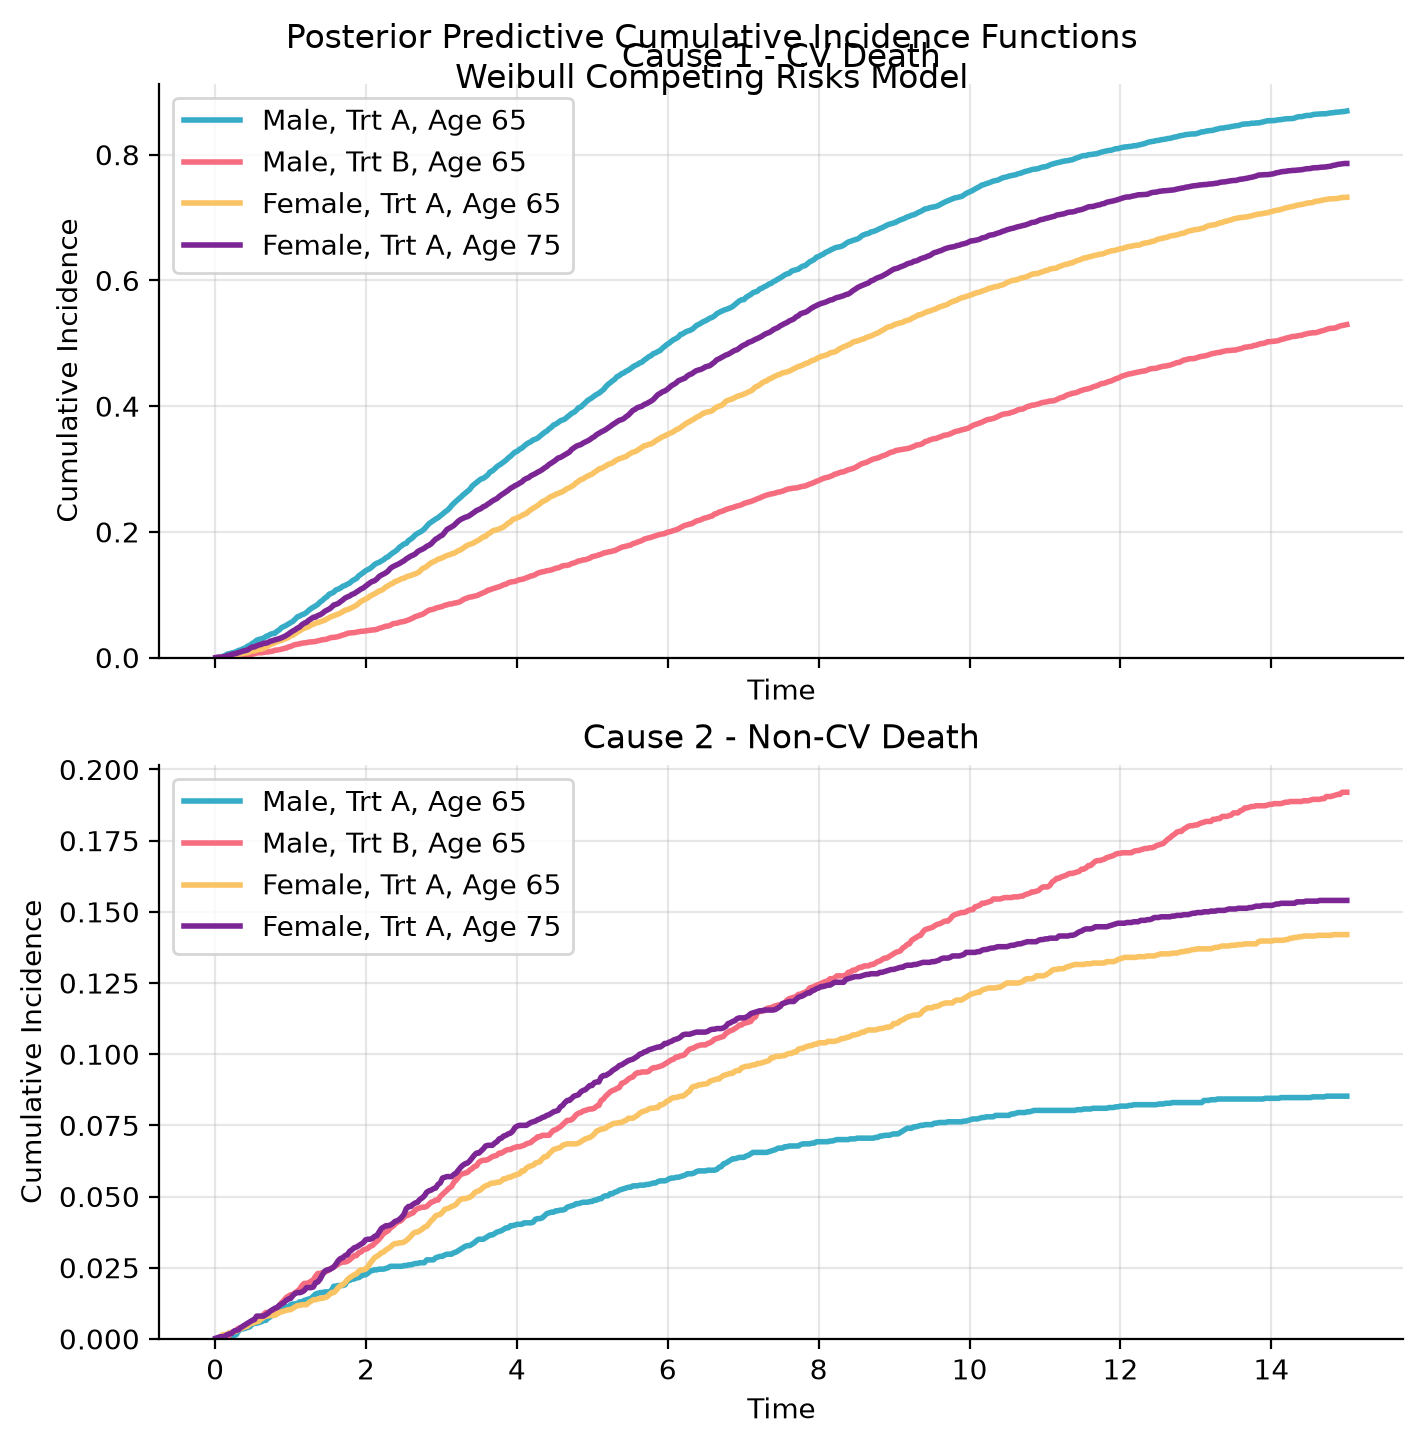

In [45]:
# | code-fold: true

# Define covariate profiles to plot
profiles = {
    "Male, Trt A, Age 65": {"age_c": 0, "sex": 1, "treatment": "A"},
    "Male, Trt B, Age 65": {"age_c": 0, "sex": 1, "treatment": "B"},
    "Female, Trt A, Age 65": {"age_c": 0, "sex": 0, "treatment": "A"},
    "Female, Trt A, Age 75": {"age_c": 10, "sex": 0, "treatment": "A"},
}

t_grid = np.linspace(0.01, 15, 500)

profile_data = pd.DataFrame.from_dict(profiles, orient="index")
predictions = model.predict(
    idata,
    data=profile_data,
    kind="time_and_cause",
    inplace=False,
    random_seed=seed,
)
response = model.response_term.label
event_times = predictions.predictions[f"{response}_time"].values.reshape(
    -1, len(profile_data)
)
event_causes = predictions.predictions[f"{response}_cause"].values.reshape(
    -1, len(profile_data)
)
cause_codes = {
    cause: code for code, cause in enumerate(model.response_term.levels, start=1)
}


def empirical_cif(event_times, event_causes, cause_code, t_grid):
    """Estimate a CIF as the posterior predictive event proportion by each time."""
    return (
        (event_times[:, np.newaxis] <= t_grid)
        & (event_causes[:, np.newaxis] == cause_code)
    ).mean(axis=0)


# Plot: 2 rows (cause 1, cause 2) × 1 column, all profiles overlaid
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

colours = ["C0", "C1", "C2", "C3"]

for index, (label, colour) in enumerate(zip(profiles, colours)):
    cif1 = empirical_cif(
        event_times[:, index], event_causes[:, index], cause_codes["cv_death"], t_grid
    )
    cif2 = empirical_cif(
        event_times[:, index],
        event_causes[:, index],
        cause_codes["noncv_death"],
        t_grid,
    )

    axes[0].plot(t_grid, cif1, color=f"C{index}", lw=2, label=label)
    axes[1].plot(t_grid, cif2, color=f"C{index}", lw=2, label=label)

axes[0].set(
    xlabel="Time",
    ylabel="Cumulative Incidence",
    ylim=(0, None),
    title="Cause 1 - CV Death",
)
axes[0].legend(fontsize=10, loc="upper left")
axes[0].grid(alpha=0.3)

axes[1].set(
    xlabel="Time",
    ylabel="Cumulative Incidence",
    ylim=(0, None),
    title="Cause 2 - Non-CV Death",
)
axes[1].legend(fontsize=10, loc="upper left")
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Posterior Predictive Cumulative Incidence Functions\n"
    "Weibull Competing Risks Model",
    y=1.01,
);

Treatment B appears protective against CV death, which is the clinically dominant outcome. See the decline in incidence for males with the treatment in the top panel. But note the reversal effect for Males on Trt A in the non-CV death, they have least incidence of experiencing death, this could reflect the interaction effect of the competing risks. The pool with of males on treatment A that survive to experience non-CV might be especially healthy. We would miss this interaction if we hadn't modelled both phenomena.

Sanity check: $F_1(t) + F_2(t) + S(t) \approx 1$ for each profile:

In [46]:
cif1 = empirical_cif(
    event_times[:, 0], event_causes[:, 0], cause_codes["cv_death"], t_grid
)
cif2 = empirical_cif(
    event_times[:, 0], event_causes[:, 0], cause_codes["noncv_death"], t_grid
)
surv = (event_times[:, 0, np.newaxis] > t_grid).astype(float)

partition = cif1 + cif2 + surv.mean(0)
np.allclose(partition, 1.0)

True

## Conclusion: the shape of accumulation

We began this series of notebooks with the Sorites paradox: one grain of sand is not a heap, but if you keep adding grains, eventually it becomes one. Survival analysis models this process and tracks the gradual accumulation of risk that culminates in a qualitative change.

In the discrete-time notebook, we approximated this accumulation period by period: each interval contributed a small increment of risk, and the person-period data structure made that accumulation explicit. The cloglog link ensured that our linear predictor operated on the natural currency of accumulated risk - the log-survival scale. That approach was flexible and assumption-light, but it discretized what is often a continuous process.

In this notebook, we moved to continuous time, where the accumulation of risk is described directly by the hazard function and its integral, the cumulative hazard. The parametric families we explored embody different theories about *how* risk accumulates:

- The **Weibull** says risk accumulates at a rate that is monotonically changing. Accelerating (like aging or material fatigue) or decelerating (like infant mortality or burn-in failure), or staying constant (the memoryless exponential).
- The **log-normal** says risk builds to a peak and then recedes. A process where the danger is greatest in a critical window, after which survivors face diminishing threat.
- The **log-logistic** tells a similar story, but with a heavier tail. The danger recedes more slowly, reflecting a process where risk lingers even as it diminishes.
- The **Weibull competing-risk** model outlines how multiple parametric hazards can be operating at once. Reducing one risk gives the others more time to accumulate. These interactions are key for many applications. 

State-transition events i.e. qualitative changes in status occur everywhere: in clinical outcomes, in employee attrition, in mechanical failure, in the adoption of ideas. The challenge of survival analysis is to understand under what kind of process these changes emerge, and to let the data inform that understanding. The Bayesian approach gives us the tools to do this honestly: posterior uncertainty over parameters, model comparison via LOO, and the flexibility to encode our substantive beliefs about accumulation through the choice of model structure. 

#### Discrete vs. continuous: choosing your approach

| Feature | Discrete-Time (Cloglog) | Continuous-Time (Parametric AFT) |
|---------|------------------------|-------------------------------|
| **Baseline hazard** | Fully flexible (categorical dummies or splines) | Parametric (2 parameters) |
| **Data format** | Person-period expansion | One row per subject |
| **Coefficient interpretation** | Log hazard ratios (PH) | Log time ratios (AFT) |
| **Time scale** | Naturally discrete periods | Continuous (days, hours, etc.) |
| **Extrapolation** | No (beyond observed periods) | Yes (with caution) |
| **Assumption risk** | Minimal (baseline is flexible) | Misspecification if wrong family |
| **Computational cost** | Higher (expanded dataset) | Lower (compact data) |
| **Extensions** | Easy non-proportional hazards via interactions | Frailty models, multiple built-in survival families, competing risks |

In practice, the two approaches often give similar substantive answers. The choice depends on whether time is naturally discrete or continuous, whether you want parametric efficiency or nonparametric flexibility, and whether you prefer AFT or PH interpretation. Both are regression. Both model the accumulation of risk. They differ in how they represent time and what trade-offs they accept.

### Dissolving the paradox?

Each of these methods is a different answer to the Sorites question: *how does the heap come into being?* All at once? Gradually and relentlessly? Through a critical period that passes? The choice of parametric family is not a technical nuisance, but a substantive claim about the developmental process that leads to the event. It matters when an event occurs, not merely that it does occur. The Sorites paradox endures because it asks for a sharp boundary where none exists. The proper question asks instead about the probable rate of state-transition over time. Time is a resource, and understanding how long each state is likely to last shapes how we act within it. The paradox results from a focus on the state-change rather than the process that yields the change.




# Session info

In [47]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Thu, 17 Sep 2026

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.17.1

arviz     : 1.3.0
bambi     : 0.20.1.dev7+g5b7e1b1f4.d20260917
matplotlib: 3.11.2
numpy     : 2.4.6
pandas    : 2.3.3
preliz    : 0.27.1
pymc      : 6.3.2
pytensor  : 3.3.0
scipy     : 1.17.1

Watermark: 2.6.0



## Author

This notebook was contributed by Nathaniel Forde: https://nathanielf.github.io/
